## Модели прогнозирования объема надоя молока по Жамбылской области

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pylab import rcParams
from IPython.display import display
import math
from prophet import Prophet
pd.set_option('display.max_columns', 130)


import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

### Подготовка данных и EDA

In [2]:
df = pd.read_excel("Датасет по молоку с регрессорами.xlsx")
df.sample(10)

,Регион,Период,Молоко,Осадки,Поголовье: КРС,Температура,Цена: Молоко
1257,КАРАГАНДИНСКАЯ ОБЛАСТЬ,2023-03,16179.1,35.4,24156.0,-2.532258,248.500038
471,АТЫРАУСКАЯ ОБЛАСТЬ,2024-04,2706.1,10.0,151363.0,17.776667,125.698145
1438,КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ,2018-04,6722.3,25.3,328605.0,13.416667,97.659323
14,АКМОЛИНСКАЯ ОБЛАСТЬ,2016-03,25722.9,19.0,438683.0,-2.167742,102.846894
1091,ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ,2019-05,36800.4,9.2,700608.0,18.364516,124.306759
686,ГАЛМАТЫ,2022-03,40.2,165.7,2716.0,5.648387,NaN
1526,МАНГИСТАУСКАЯ ОБЛАСТЬ,2015-08,534.4,0.0,15230.0,26.174194,110.595269
894,ГШЫМКЕНТ,2022-12,3710.9,44.5,76312.0,-1.938710,NaN
1248,КАРАГАНДИНСКАЯ ОБЛАСТЬ,2022-06,67840.4,15.0,631414.0,20.380000,226.817307
834,ГАСТАНА,2024-07,25.1,28.9,156.0,21.767742,NaN


In [3]:
df_zhambyl = df[df['Регион'] == 'ЖАМБЫЛСКАЯ ОБЛАСТЬ']
df_zhambyl = df_zhambyl.drop('Регион', axis = 'columns')
df_zhambyl.head()

,Период,Молоко,Осадки,Поголовье: КРС,Температура,Цена: Молоко
919,2015-01,14848.0,48.5,303643.0,-2.306452,101.200000
920,2015-02,14639.9,25.3,316778.0,1.871429,99.277200
921,2015-03,15844.1,36.2,344717.0,3.958065,97.291656
922,2015-04,25219.9,25.4,357904.0,14.166667,98.264573
923,2015-05,37200.8,16.4,356641.0,20.106452,96.004487


In [4]:
df_zhambyl['Период'] = pd.to_datetime(df_zhambyl['Период'], format='%Y-%m')
df_zhambyl.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120 entries, 919 to 1038
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Период          120 non-null    datetime64[ns]
 1   Молоко          120 non-null    float64       
 2   Осадки          120 non-null    float64       
 3   Поголовье: КРС  120 non-null    float64       
 4   Температура     120 non-null    float64       
 5   Цена: Молоко    120 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 6.6 KB


In [5]:
df_zhambyl.isna().sum()

Период            0
Молоко            0
Осадки            0
Поголовье: КРС    0
Температура       0
Цена: Молоко      0
dtype: int64

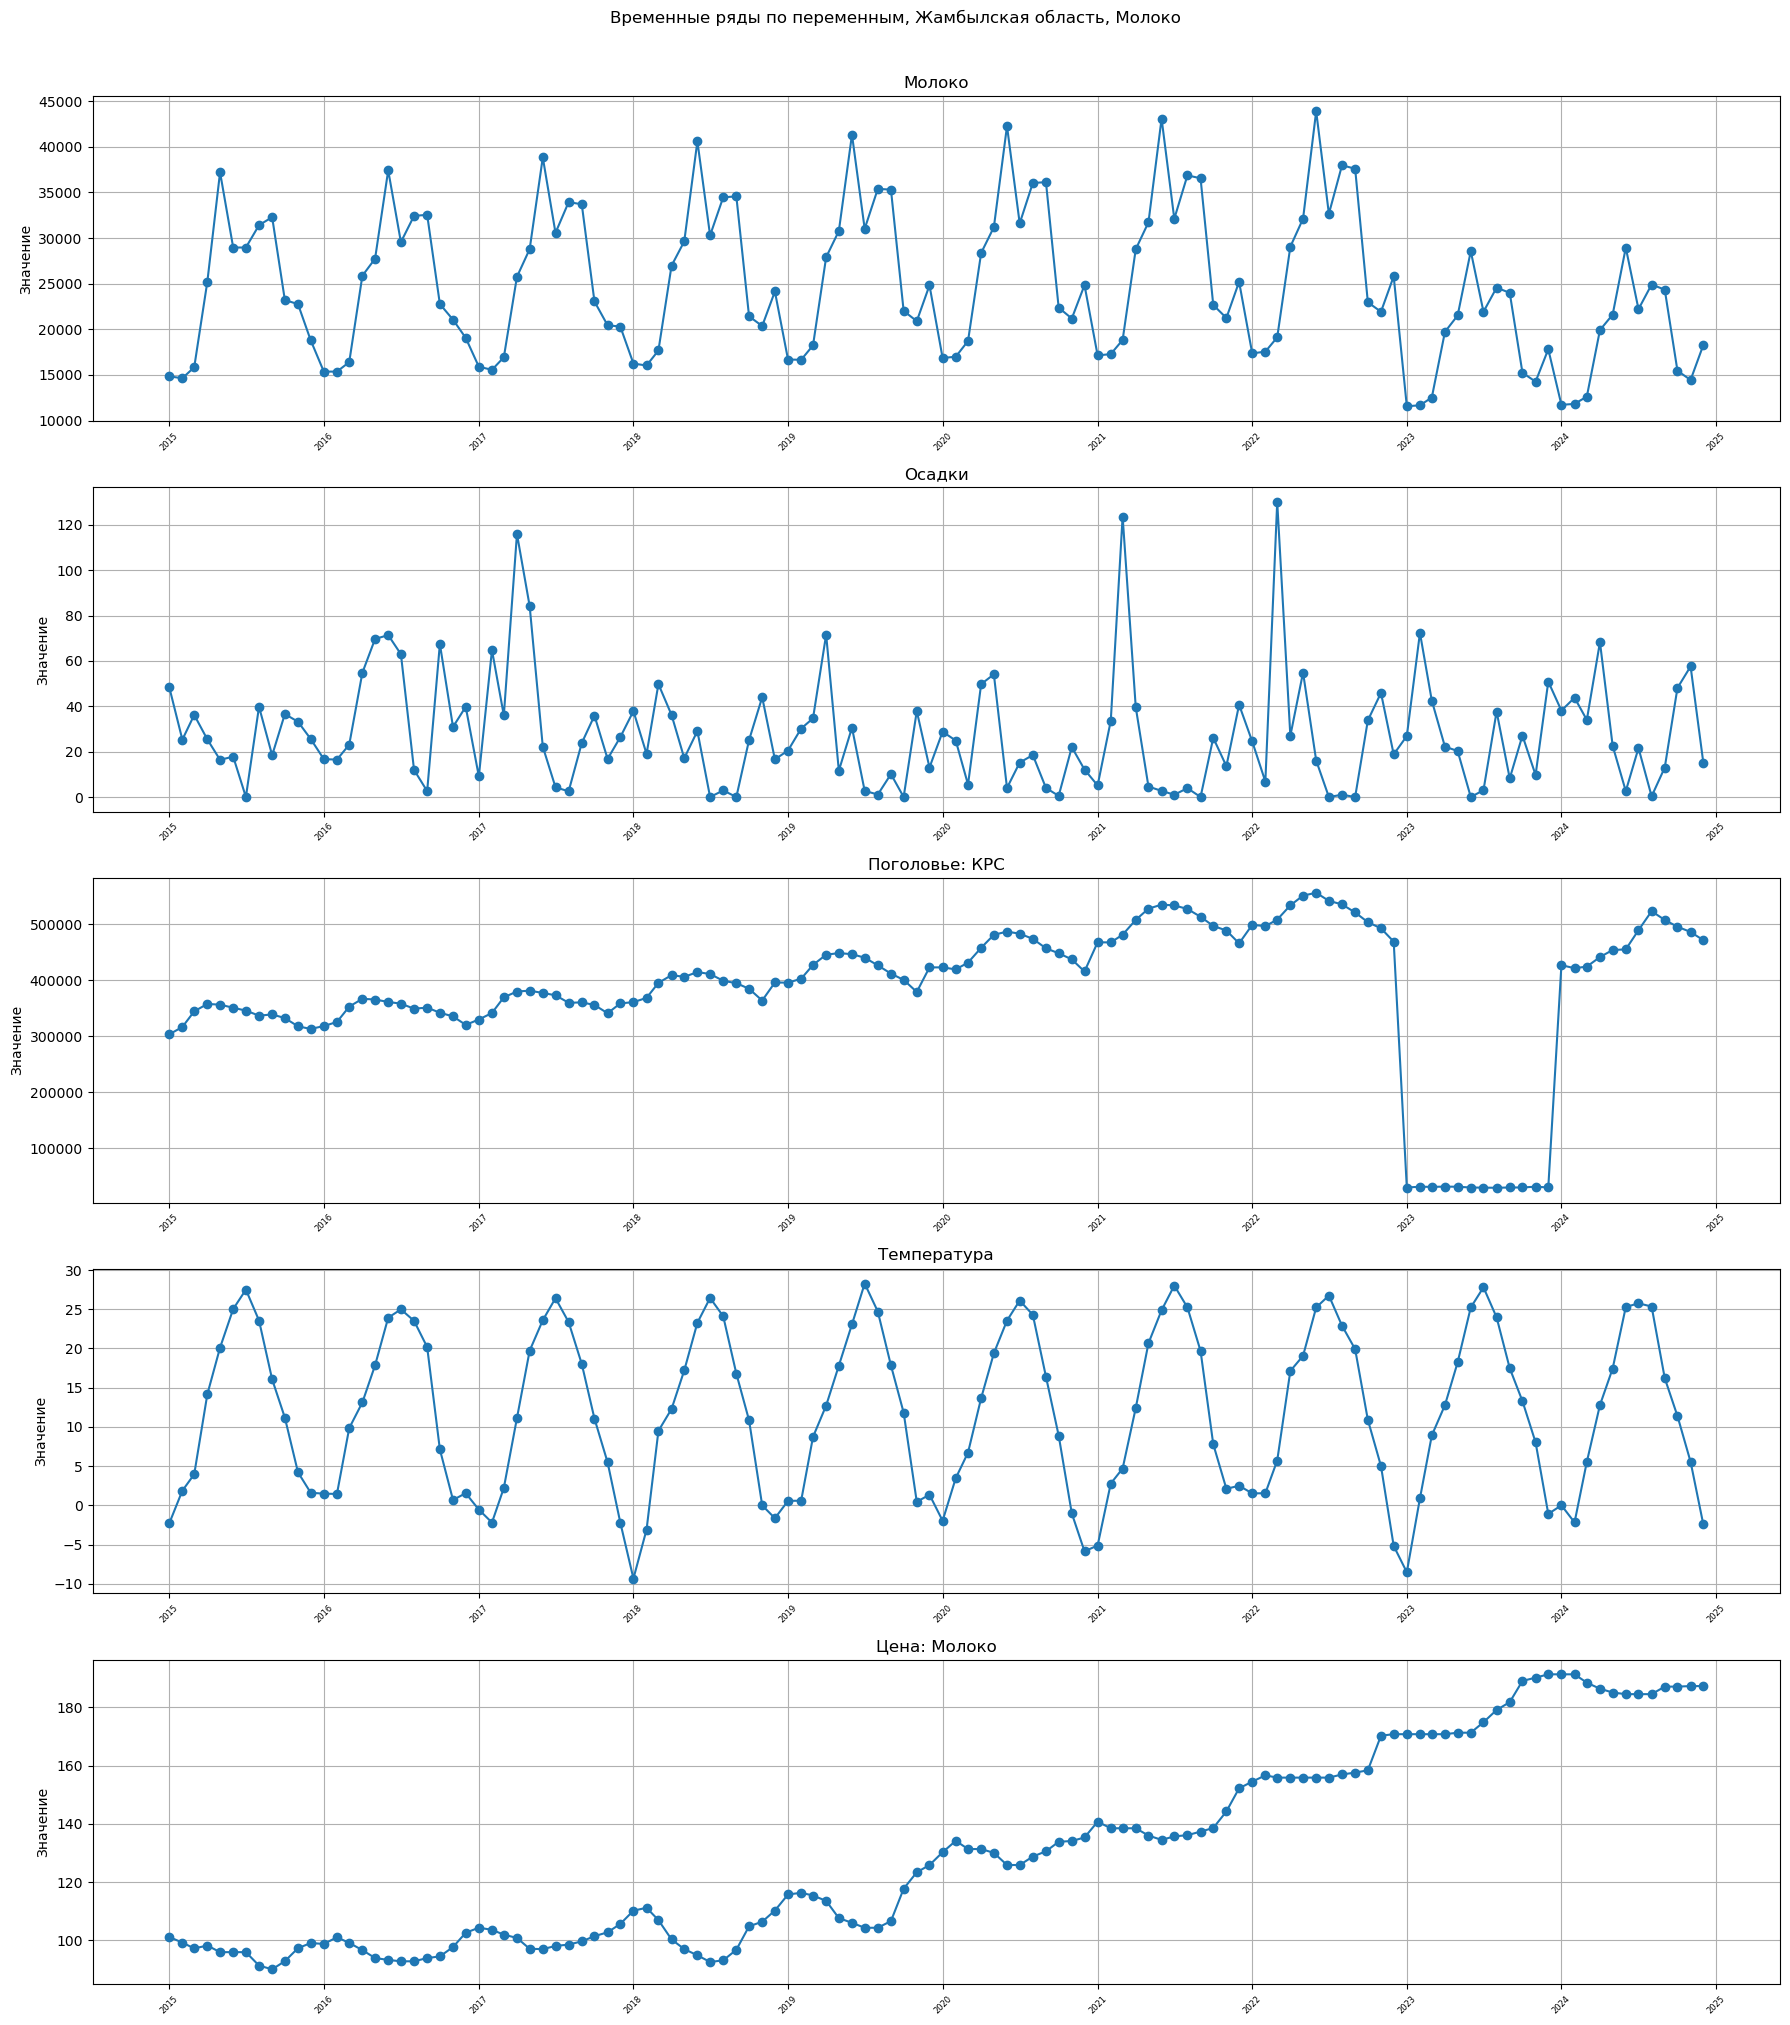

In [6]:
# Plot each variable in its own subplot
value_cols = [col for col in df_zhambyl.columns if col not in ["Период"]]

n = len(value_cols)
plt.figure(figsize=(18, 4 * n))

for i, col in enumerate(value_cols, 1):
    plt.subplot(n, 1, i)
    plt.plot(df_zhambyl["Период"], df_zhambyl[col], marker="o")
    plt.title(f"{col}")
    plt.grid(True)
    plt.ylabel("Значение")
    plt.xticks(rotation=45, fontsize = 6)

plt.suptitle("Временные ряды по переменным, Жамбылская область, Молоко", y=1.01)
plt.tight_layout()
plt.show()

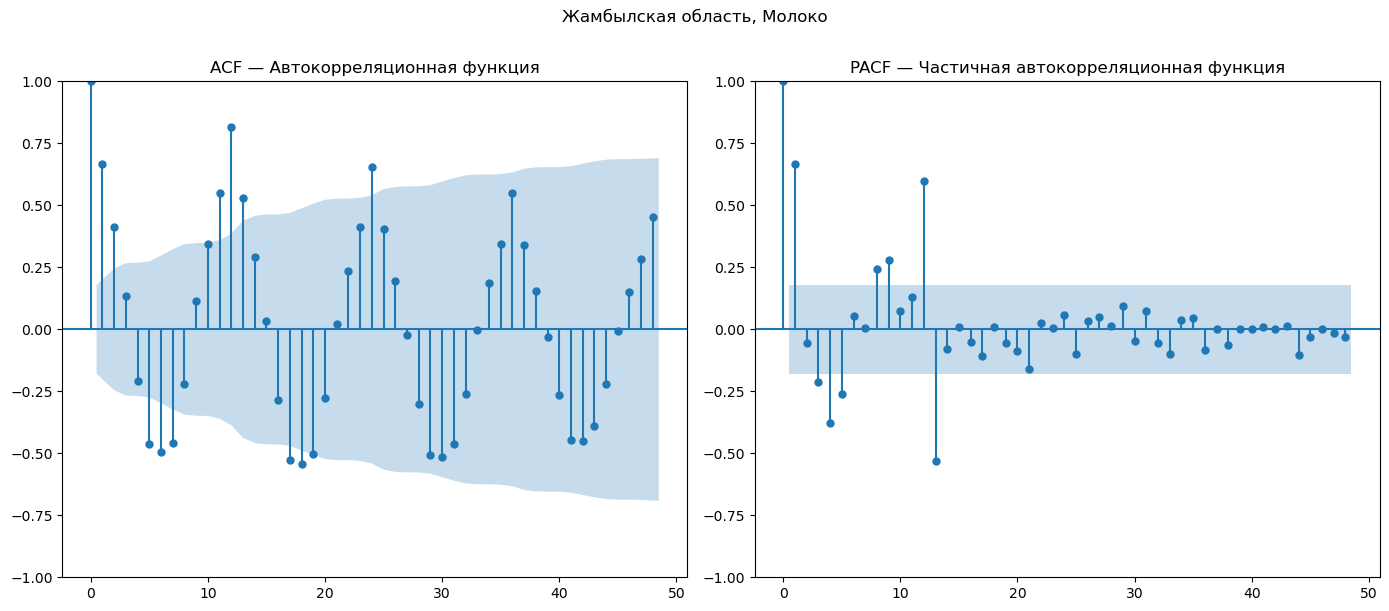

In [7]:
y = df_zhambyl["Молоко"].sort_index()

# Plot ACF and PACF
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_acf(y, lags=48, ax=plt.gca(), title="ACF — Автокорреляционная функция")

plt.subplot(1, 2, 2)
plot_pacf(y, lags=48, ax=plt.gca(), title="PACF — Частичная автокорреляционная функция", method="ywm")
plt.suptitle("Жамбылская область, Молоко", y=1.01)

plt.tight_layout()
plt.show()

Графики автокорреляционной и частичной автокорреляционной функций указывают на **сильную взаимосвязь показателей текущего месяца со значениями следующих 2 месяцев** и на возможную **годовую сезонность** (пик на +12 месяцев). 

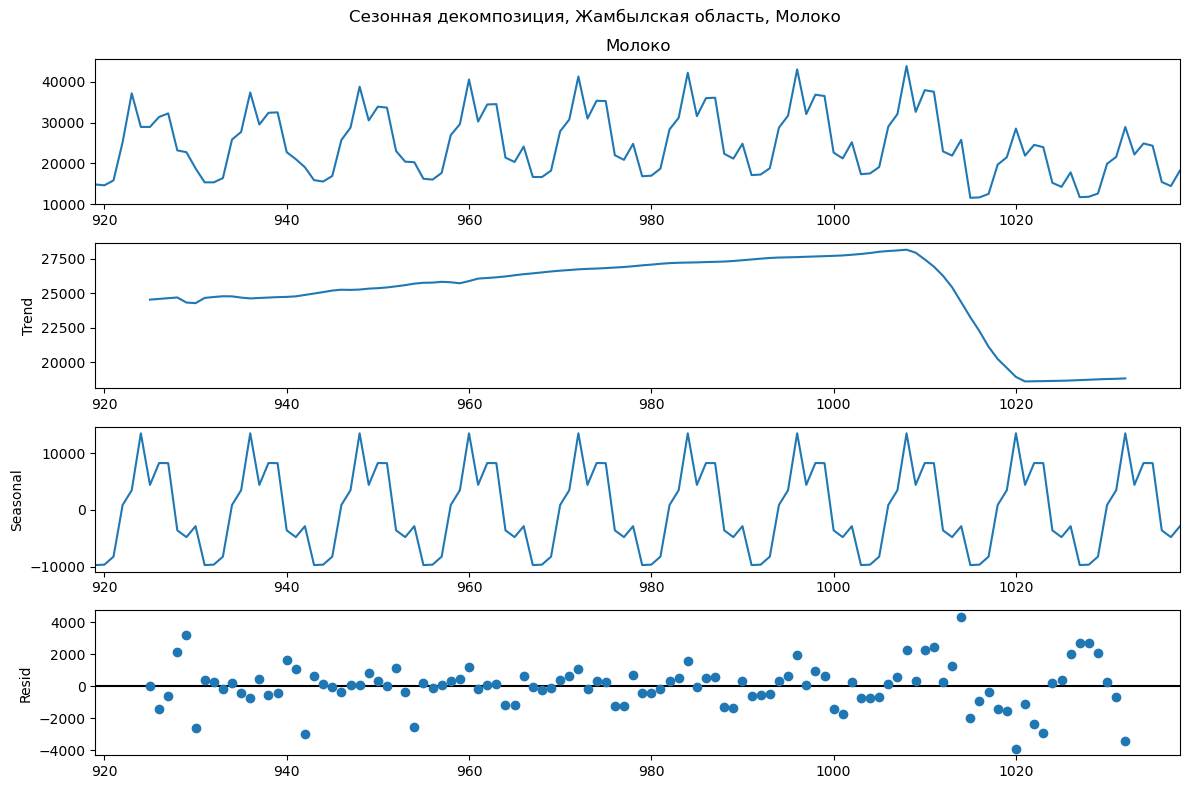

In [8]:
# Perform decomposition (period=12 for monthly data)
decomposition = seasonal_decompose(df_zhambyl["Молоко"], model="additive", period=12)

# Plot with larger figure size
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Сезонная декомпозиция, Жамбылская область, Молоко", fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
# Run ADF test
result = adfuller(df_zhambyl["Молоко"])

# Display results
print("📊 Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

# Interpretation
if result[1] < 0.05:
    print("✅ The series is likely **stationary** (reject H₀).")
else:
    print("❌ The series is likely **non-stationary** (fail to reject H₀).")


📊 Augmented Dickey-Fuller Test Results:
ADF Statistic: -1.7691
p-value: 0.3959
Critical Value (1%): -3.4936
Critical Value (5%): -2.8892
Critical Value (10%): -2.5815
❌ The series is likely **non-stationary** (fail to reject H₀).


Результаты теста ADF указывают на **нестационарность** временного ряда.

In [10]:
df_zhambyl

,Период,Молоко,Осадки,Поголовье: КРС,Температура,Цена: Молоко
919,2015-01-01,14848.0,48.5,303643.0,-2.306452,101.200000
920,2015-02-01,14639.9,25.3,316778.0,1.871429,99.277200
921,2015-03-01,15844.1,36.2,344717.0,3.958065,97.291656
922,2015-04-01,25219.9,25.4,357904.0,14.166667,98.264573
923,2015-05-01,37200.8,16.4,356641.0,20.106452,96.004487
...,...,...,...,...,...,...
1034,2024-08-01,24907.0,0.3,523425.0,25.345161,184.493767
1035,2024-09-01,24341.0,13.0,507738.0,16.213333,187.076680
1036,2024-10-01,15457.5,48.1,495712.0,11.387097,187.076680
1037,2024-11-01,14452.4,57.6,486310.0,5.546667,187.263756


In [11]:
# Создание лагов t-1 до t-6 для переменных
for lag in range(1, 7):
    df_zhambyl[f"Молоко_t-{lag}"] = df_zhambyl["Молоко"].shift(lag)
    df_zhambyl[f"Температура_t-{lag}"] = df_zhambyl["Температура"].shift(lag)
    df_zhambyl[f"Осадки_t-{lag}"] = df_zhambyl["Осадки"].shift(lag)
    df_zhambyl[f"Поголовье: КРС_t-{lag}"] = df_zhambyl["Поголовье: КРС"].shift(lag)
    df_zhambyl[f"Цена: Молоко_t-{lag}"] = df_zhambyl["Цена: Молоко"].shift(lag)

df_zhambyl_full = df_zhambyl[["Период", "Молоко", 
                            "Молоко_t-1", "Молоко_t-2", "Молоко_t-3", "Молоко_t-4", "Молоко_t-5", "Молоко_t-6",
                            "Температура", "Температура_t-1", "Температура_t-2", "Температура_t-3", "Температура_t-4", "Температура_t-5", "Температура_t-6",
                            "Осадки", "Осадки_t-1", "Осадки_t-2", "Осадки_t-3", "Осадки_t-4", "Осадки_t-5", "Осадки_t-6",
                            "Поголовье: КРС", "Поголовье: КРС_t-1", "Поголовье: КРС_t-2", "Поголовье: КРС_t-3", "Поголовье: КРС_t-4", "Поголовье: КРС_t-5", "Поголовье: КРС_t-6",
                            "Цена: Молоко", "Цена: Молоко_t-1", "Цена: Молоко_t-2", "Цена: Молоко_t-3", "Цена: Молоко_t-4", "Цена: Молоко_t-5", "Цена: Молоко_t-6"]]
df_zhambyl_full

,Период,Молоко,Молоко_t-1,Молоко_t-2,Молоко_t-3,Молоко_t-4,Молоко_t-5,Молоко_t-6,Температура,Температура_t-1,Температура_t-2,Температура_t-3,Температура_t-4,Температура_t-5,Температура_t-6,Осадки,Осадки_t-1,Осадки_t-2,Осадки_t-3,Осадки_t-4,Осадки_t-5,Осадки_t-6,Поголовье: КРС,Поголовье: КРС_t-1,Поголовье: КРС_t-2,Поголовье: КРС_t-3,Поголовье: КРС_t-4,Поголовье: КРС_t-5,Поголовье: КРС_t-6,Цена: Молоко,Цена: Молоко_t-1,Цена: Молоко_t-2,Цена: Молоко_t-3,Цена: Молоко_t-4,Цена: Молоко_t-5,Цена: Молоко_t-6
919,2015-01-01,14848.0,NaN,NaN,NaN,NaN,NaN,NaN,-2.306452,NaN,NaN,NaN,NaN,NaN,NaN,48.5,NaN,NaN,NaN,NaN,NaN,NaN,303643.0,NaN,NaN,NaN,NaN,NaN,NaN,101.200000,NaN,NaN,NaN,NaN,NaN,NaN
920,2015-02-01,14639.9,14848.0,NaN,NaN,NaN,NaN,NaN,1.871429,-2.306452,NaN,NaN,NaN,NaN,NaN,25.3,48.5,NaN,NaN,NaN,NaN,NaN,316778.0,303643.0,NaN,NaN,NaN,NaN,NaN,99.277200,101.200000,NaN,NaN,NaN,NaN,NaN
921,2015-03-01,15844.1,14639.9,14848.0,NaN,NaN,NaN,NaN,3.958065,1.871429,-2.306452,NaN,NaN,NaN,NaN,36.2,25.3,48.5,NaN,NaN,NaN,NaN,344717.0,316778.0,303643.0,NaN,NaN,NaN,NaN,97.291656,99.277200,101.200000,NaN,NaN,NaN,NaN
922,2015-04-01,25219.9,15844.1,14639.9,14848.0,NaN,NaN,NaN,14.166667,3.958065,1.871429,-2.306452,NaN,NaN,NaN,25.4,36.2,25.3,48.5,NaN,NaN,NaN,357904.0,344717.0,316778.0,303643.0,NaN,NaN,NaN,98.264573,97.291656,99.277200,101.200000,NaN,NaN,NaN
923,2015-05-01,37200.8,25219.9,15844.1,14639.9,14848.0,NaN,NaN,20.106452,14.166667,3.958065,1.871429,-2.306452,NaN,NaN,16.4,25.4,36.2,25.3,48.5,NaN,NaN,356641.0,357904.0,344717.0,316778.0,303643.0,NaN,NaN,96.004487,98.264573,97.291656,99.277200,101.200000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,2024-08-01,24907.0,22208.3,28942.5,21610.9,19916.2,12628.7,11830.5,25.345161,25.758065,25.286667,17.441935,12.786667,5.535484,-2.175862,0.3,21.6,2.6,22.6,68.3,34.0,43.8,523425.0,489551.0,455255.0,454158.0,441599.0,424527.0,421726.0,184.493767,184.493767,184.493767,185.048914,186.353387,188.426074,191.295507
1035,2024-09-01,24341.0,24907.0,22208.3,28942.5,21610.9,19916.2,12628.7,16.213333,25.345161,25.758065,25.286667,17.441935,12.786667,5.535484,13.0,0.3,21.6,2.6,22.6,68.3,34.0,507738.0,523425.0,489551.0,455255.0,454158.0,441599.0,424527.0,187.076680,184.493767,184.493767,184.493767,185.048914,186.353387,188.426074
1036,2024-10-01,15457.5,24341.0,24907.0,22208.3,28942.5,21610.9,19916.2,11.387097,16.213333,25.345161,25.758065,25.286667,17.441935,12.786667,48.1,13.0,0.3,21.6,2.6,22.6,68.3,495712.0,507738.0,523425.0,489551.0,455255.0,454158.0,441599.0,187.076680,187.076680,184.493767,184.493767,184.493767,185.048914,186.353387
1037,2024-11-01,14452.4,15457.5,24341.0,24907.0,22208.3,28942.5,21610.9,5.546667,11.387097,16.213333,25.345161,25.758065,25.286667,17.441935,57.6,48.1,13.0,0.3,21.6,2.6,22.6,486310.0,495712.0,507738.0,523425.0,489551.0,455255.0,454158.0,187.263756,187.076680,187.076680,184.493767,184.493767,184.493767,185.048914


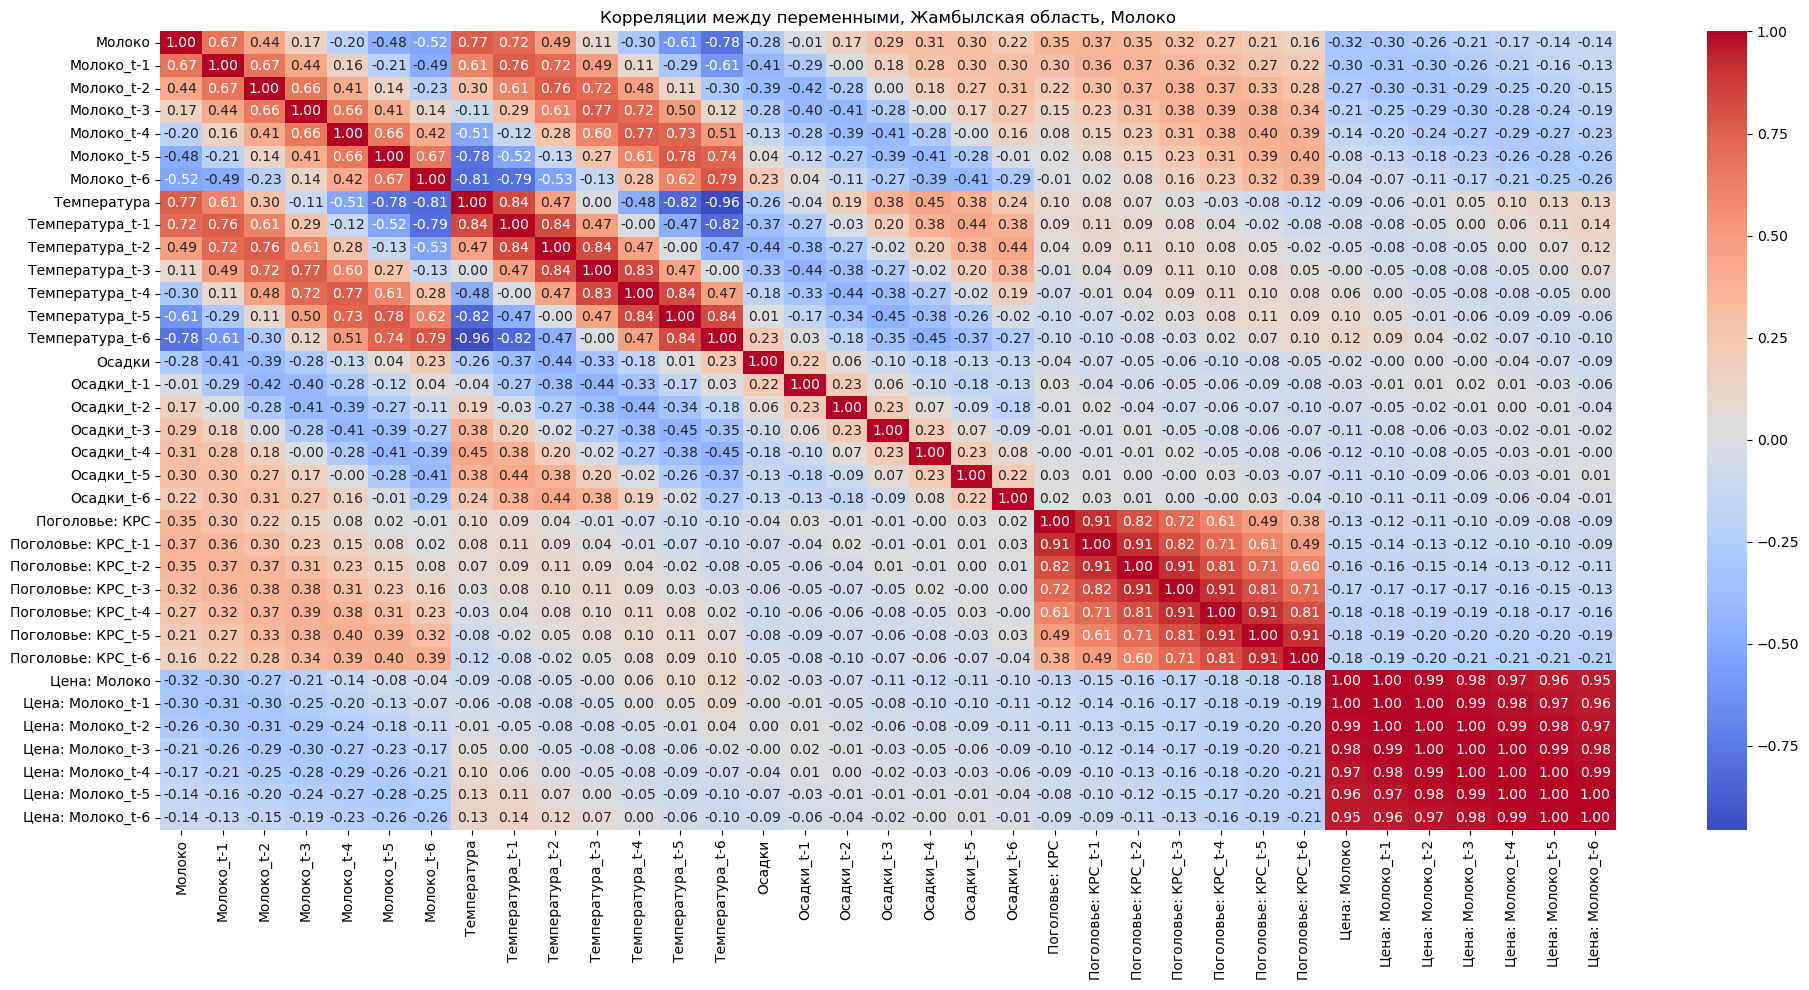

In [12]:
df_corr = df_zhambyl_full[[col for col in df_zhambyl_full.columns if col not in ["Период"]]].dropna().copy()

# 1. Correlation matrix
corr_matrix = df_corr.corr()

# 2. Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляции между переменными, Жамбылская область, Молоко")
plt.tight_layout()
plt.show()

*ВЫВОДЫ ПО КОРРЕЛЯЦИИ*

In [13]:
# Set your target variable
target_var = "Молоко"

# Get correlations with the target variable
target_corr = corr_matrix[target_var].drop(target_var)  # exclude self-correlation

# Keep only features with |correlation| >= 0.5
selected_vars = target_corr[abs(target_corr) >= 0.5].index.tolist()

print("✅ Отобранные переменные с корреляцией >= 0.5:")
print(selected_vars)

# Optionally: create new dataframe with selected variables + target
df_selected = df_zhambyl_full[['Период'] + selected_vars + [target_var]]
df_selected

✅ Отобранные переменные с корреляцией >= 0.5:
['Молоко_t-1', 'Молоко_t-6', 'Температура', 'Температура_t-1', 'Температура_t-5', 'Температура_t-6']


,Период,Молоко_t-1,Молоко_t-6,Температура,Температура_t-1,Температура_t-5,Температура_t-6,Молоко
919,2015-01-01,NaN,NaN,-2.306452,NaN,NaN,NaN,14848.0
920,2015-02-01,14848.0,NaN,1.871429,-2.306452,NaN,NaN,14639.9
921,2015-03-01,14639.9,NaN,3.958065,1.871429,NaN,NaN,15844.1
922,2015-04-01,15844.1,NaN,14.166667,3.958065,NaN,NaN,25219.9
923,2015-05-01,25219.9,NaN,20.106452,14.166667,NaN,NaN,37200.8
...,...,...,...,...,...,...,...,...
1034,2024-08-01,22208.3,11830.5,25.345161,25.758065,5.535484,-2.175862,24907.0
1035,2024-09-01,24907.0,12628.7,16.213333,25.345161,12.786667,5.535484,24341.0
1036,2024-10-01,24341.0,19916.2,11.387097,16.213333,17.441935,12.786667,15457.5
1037,2024-11-01,15457.5,21610.9,5.546667,11.387097,25.286667,17.441935,14452.4


In [14]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()

X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Молоко"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
1,Молоко_t-1,2.678799
2,Молоко_t-6,3.679677
5,Температура_t-5,8.607504
4,Температура_t-1,10.911218
3,Температура,17.066886
6,Температура_t-6,17.192006
0,const,114.185175


Step-by-Step Strategy to Handle High VIFs:

Sort VIFs in descending order
Drop variables one at a time, starting with the one that has the highest VIF.

Check domain relevance
Keep variables that are theoretically important or core to your hypothesis, even if VIF is high.

Evaluate correlation matrix
If two variables have high correlation with each other, and both have high VIFs, drop the one less correlated with the target.

Recalculate VIF after each drop
After dropping one variable, recalculate all VIFs. Sometimes removing just one variable significantly reduces others.

Use stepwise selection (optional)
Automated methods like backward elimination can help drop redundant predictors based on model fit and VIF thresholds.

In [15]:
df_selected = df_selected.drop(columns = ['Молоко_t-6', 'Температура', 'Температура_t-1', 'Температура_t-5'])
df_selected

,Период,Молоко_t-1,Температура_t-6,Молоко
919,2015-01-01,NaN,NaN,14848.0
920,2015-02-01,14848.0,NaN,14639.9
921,2015-03-01,14639.9,NaN,15844.1
922,2015-04-01,15844.1,NaN,25219.9
923,2015-05-01,25219.9,NaN,37200.8
...,...,...,...,...
1034,2024-08-01,22208.3,-2.175862,24907.0
1035,2024-09-01,24907.0,5.535484,24341.0
1036,2024-10-01,24341.0,12.786667,15457.5
1037,2024-11-01,15457.5,17.441935,14452.4


In [16]:
df_vif = df_selected[[col for col in df_selected.columns if col not in ["Период"]]].dropna().copy()
X_vif = add_constant(df_vif[[i for i in df_vif.columns if i != "Молоко"]])

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data.sort_values('VIF')

,Variable,VIF
1,Молоко_t-1,1.589133
2,Температура_t-6,1.589133
0,const,25.567182


In [17]:
df_selected = df_selected.dropna().copy()
df_selected

,Период,Молоко_t-1,Температура_t-6,Молоко
925,2015-07-01,28958.5,-2.306452,28958.5
926,2015-08-01,28958.5,1.871429,31406.2
927,2015-09-01,31406.2,3.958065,32281.7
928,2015-10-01,32281.7,14.166667,23204.3
929,2015-11-01,23204.3,20.106452,22760.9
...,...,...,...,...
1034,2024-08-01,22208.3,-2.175862,24907.0
1035,2024-09-01,24907.0,5.535484,24341.0
1036,2024-10-01,24341.0,12.786667,15457.5
1037,2024-11-01,15457.5,17.441935,14452.4


### Models

#### Многофакторная регрессия

In [18]:
# Define target and features
y = df_selected["Молоко"]
X = df_selected.drop(columns=["Период", "Молоко"])

# Add constant term
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Молоко   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     111.5
Date:                Tue, 19 Aug 2025   Prob (F-statistic):           2.83e-27
Time:                        15:54:58   Log-Likelihood:                -1123.3
No. Observations:                 114   AIC:                             2253.
Df Residuals:                     111   BIC:                             2261.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.216e+04   2209.727     

In [19]:
df_selected

,Период,Молоко_t-1,Температура_t-6,Молоко
925,2015-07-01,28958.5,-2.306452,28958.5
926,2015-08-01,28958.5,1.871429,31406.2
927,2015-09-01,31406.2,3.958065,32281.7
928,2015-10-01,32281.7,14.166667,23204.3
929,2015-11-01,23204.3,20.106452,22760.9
...,...,...,...,...
1034,2024-08-01,22208.3,-2.175862,24907.0
1035,2024-09-01,24907.0,5.535484,24341.0
1036,2024-10-01,24341.0,12.786667,15457.5
1037,2024-11-01,15457.5,17.441935,14452.4


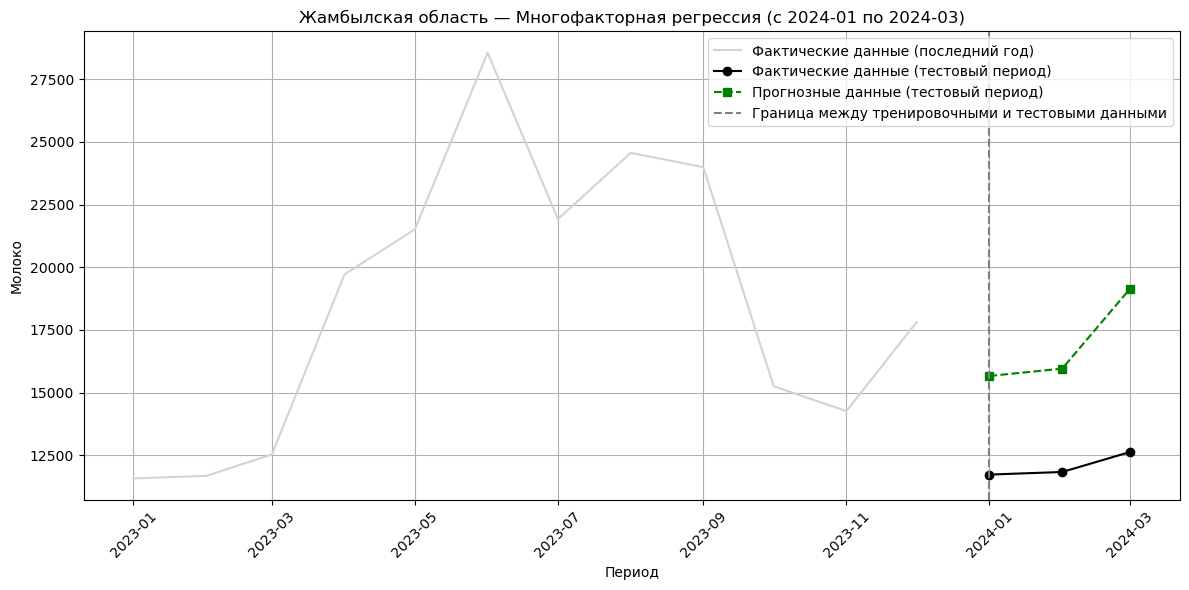

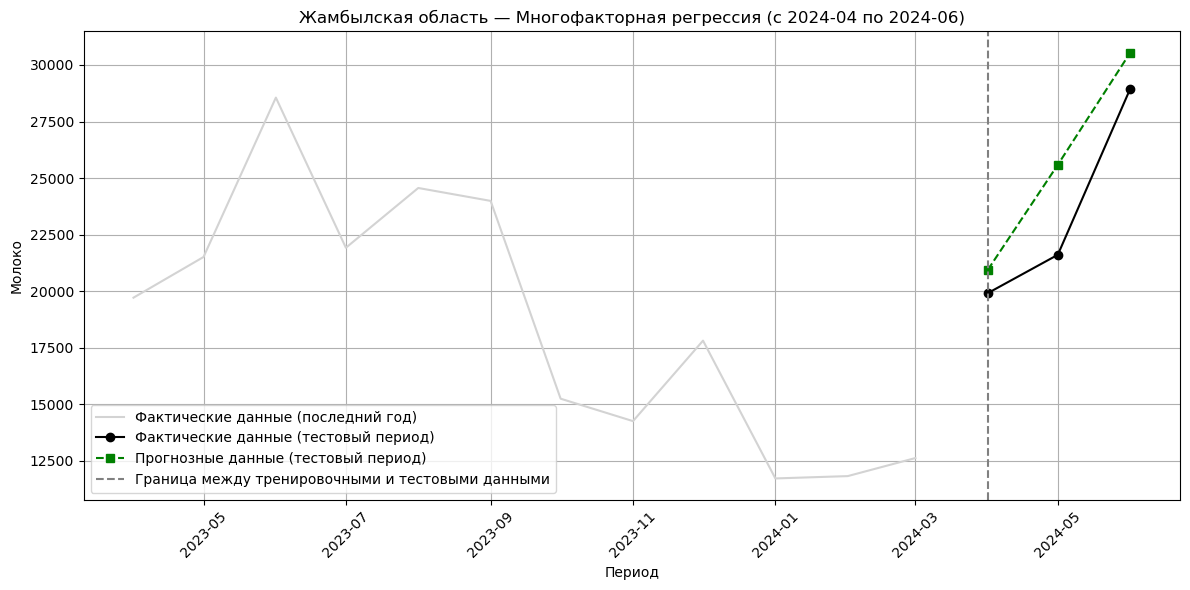

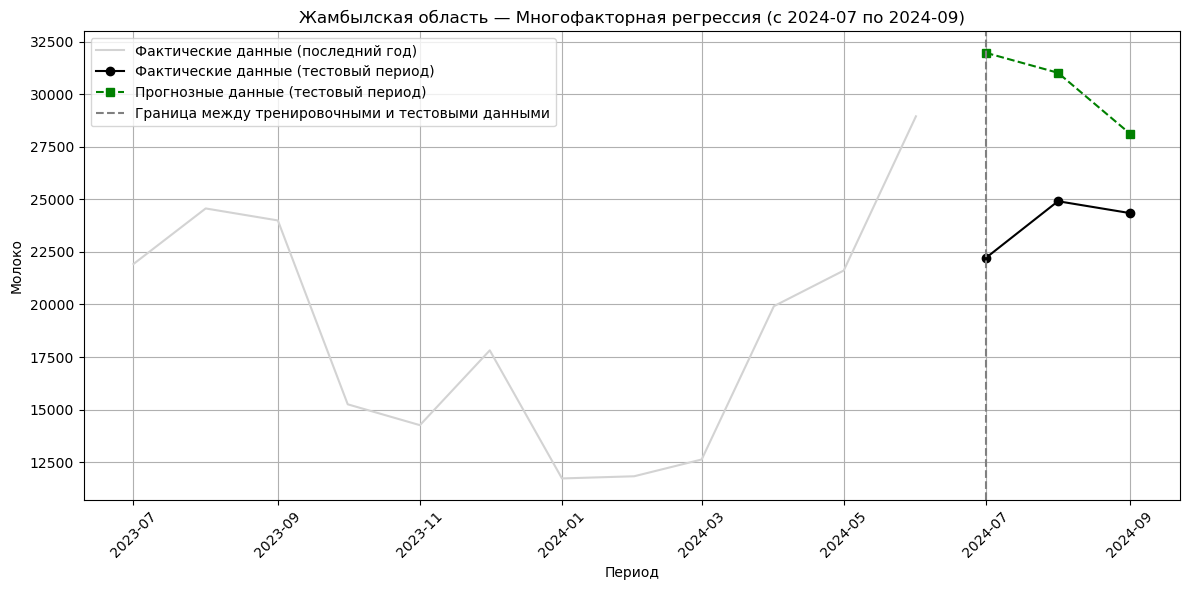

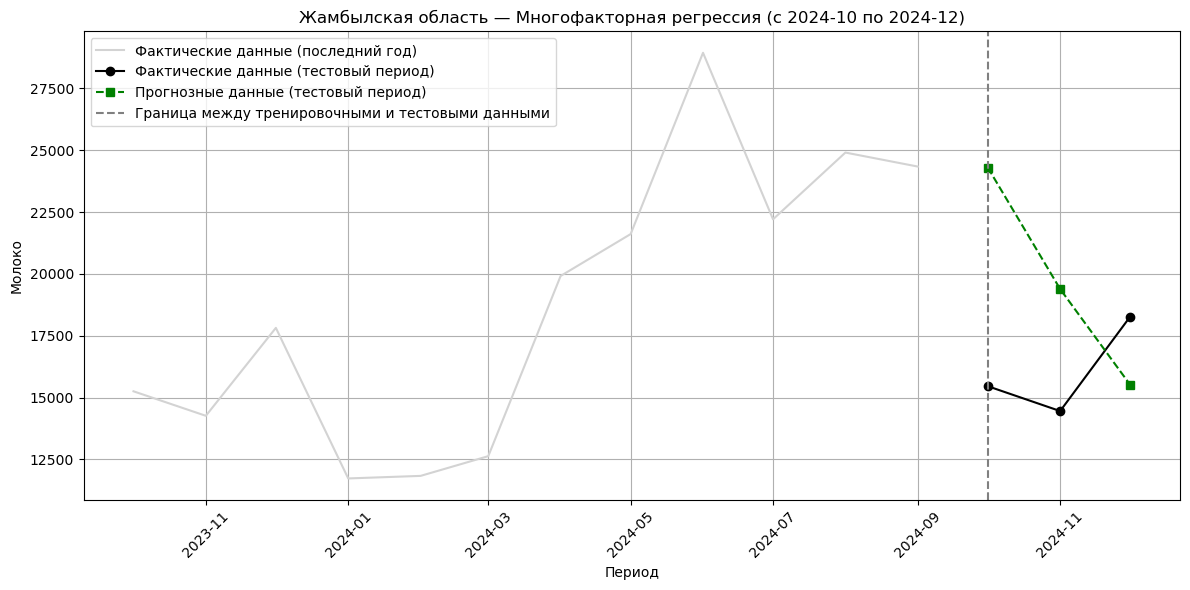

In [20]:
df = df_selected.sort_values("Период").copy()

target = "Молоко"
features = [col for col in df_selected.columns if col not in ['Период', 'Молоко']]

results = []

# Define 4 rolling test sets for 2024
start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

for start in start_dates:
    test_start = pd.to_datetime(start)
    test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Жамбылская область — Многофакторная регрессия (с {start} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Молоко")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-01 to 2024-03  5000.198620  4859.776885  40.014781
1  2024-04 to 2024-06  2545.203335  2201.233434   9.696963
2  2024-07 to 2024-09  6992.387077  6543.996464  27.977687
3  2024-10 to 2024-12  6059.466003  5511.492264  35.480610
4             Average  5149.313759  4779.124762  28.292510


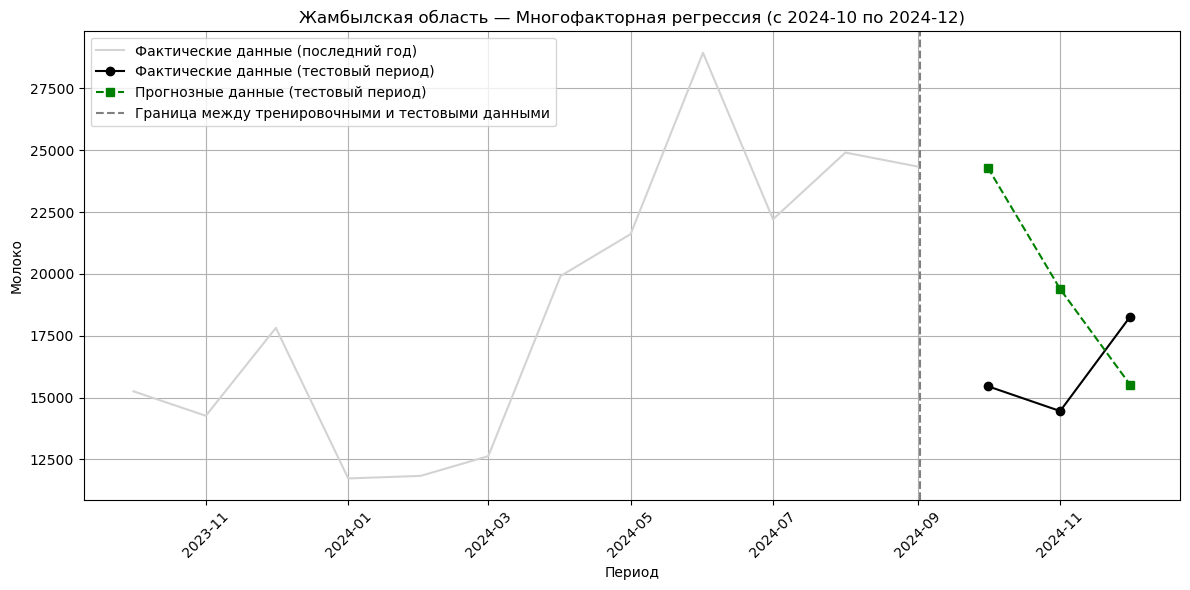

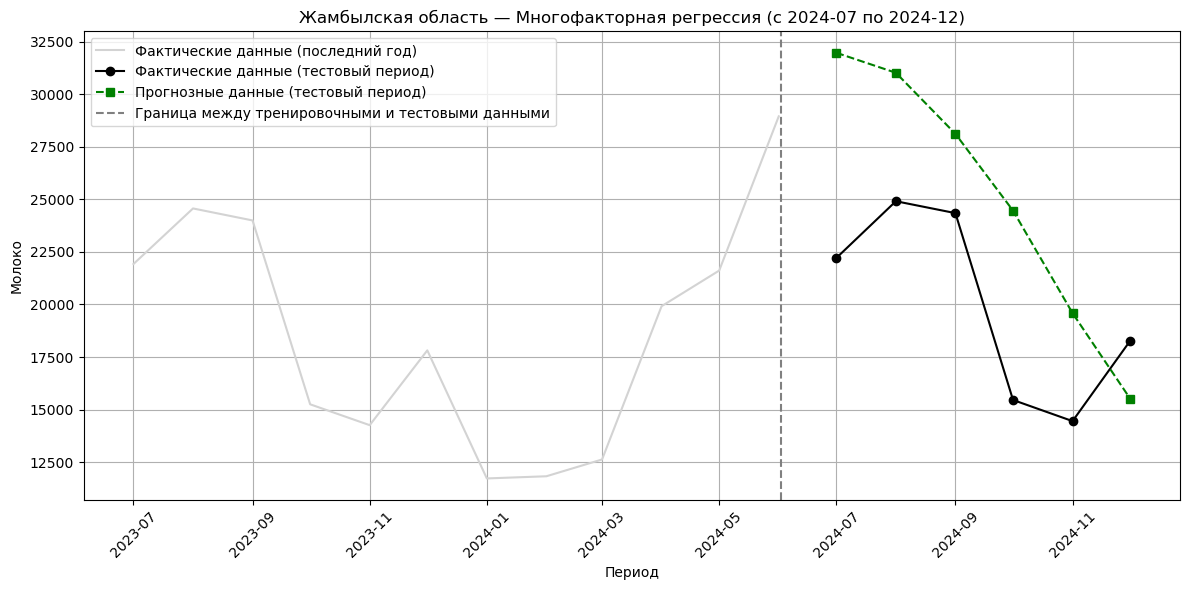

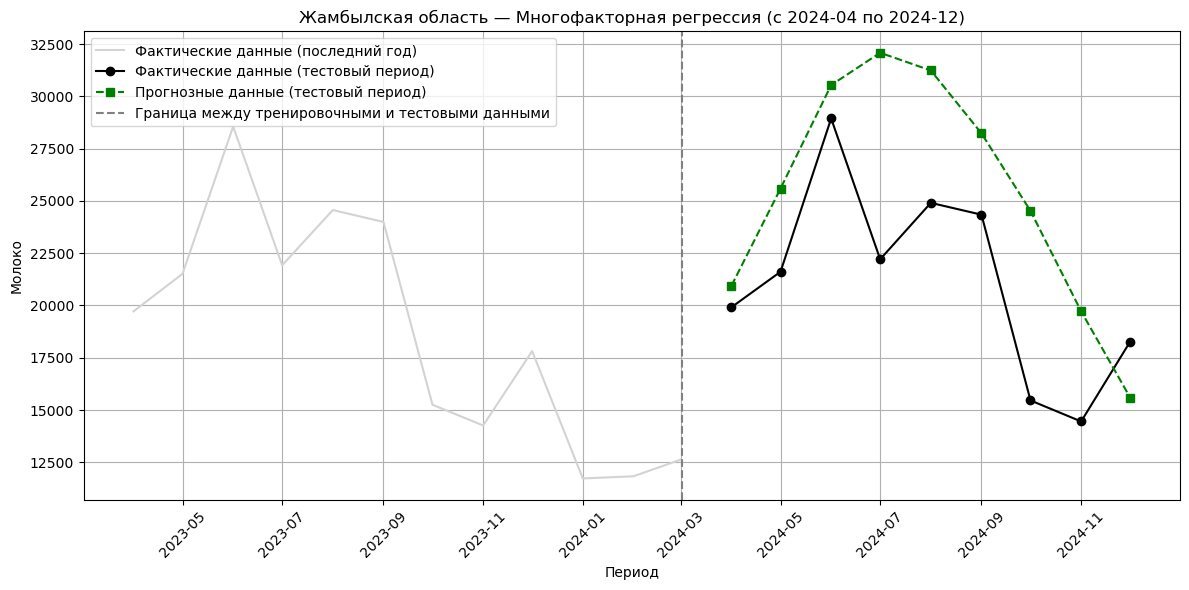

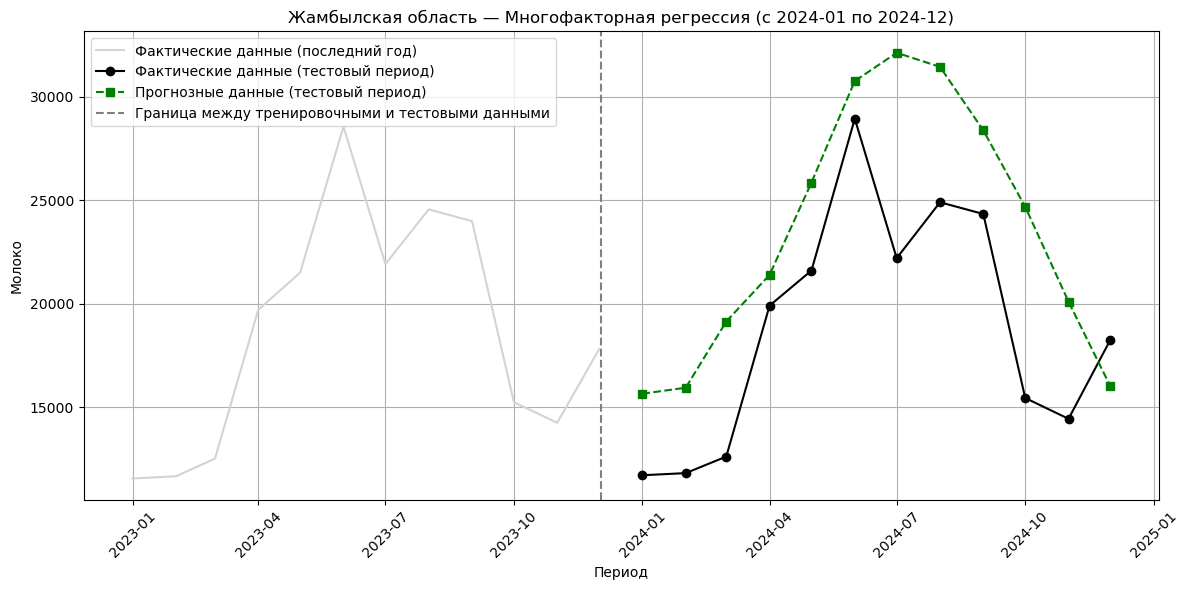

In [22]:
results = []

# Define 4 rolling test sets for 2024
horizons = [3, 6, 9, 12]

for horizon in horizons:

    test_end = pd.to_datetime("2024-12")
    test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

    # Split data
    train_df = df[df["Период"] < test_start]
    test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

    X_train = sm.add_constant(train_df[features])
    y_train = train_df[target]

    X_test = sm.add_constant(test_df[features])
    y_test = test_df[target]

    # Fit and predict
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = (np.abs((y_test - y_pred) / y_test).mean()) * 100
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        # "R²": r2
    })
    plt.figure(figsize=(12, 6))
    last_train_year = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
    plt.plot(last_train_year["Период"], last_train_year[target], color="lightgray", label="Фактические данные (последний год)")

    plt.plot(test_df["Период"], y_test.values, marker="o", color="black", label="Фактические данные (тестовый период)")
    plt.plot(test_df["Период"], y_pred.values, marker="s", linestyle="--", color="green", label="Прогнозные данные (тестовый период)")

    plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
    plt.title(f"Жамбылская область — Многофакторная регрессия (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
    plt.xlabel("Период")
    plt.ylabel("Молоко")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [23]:
# Convert to DataFrame
results_df = pd.DataFrame(results)
avg_row = results_df.mean(numeric_only=True).to_dict()
avg_row["Test period"] = "Average"
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# Show results
print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-10 to 2024-12  6059.466003  5511.492264  35.480610
1  2024-07 to 2024-12  6603.467416  6086.476831  32.124675
2  2024-04 to 2024-12  5669.388865  4856.731593  24.966932
3  2024-01 to 2024-12  5613.822481  4980.107319  29.342465
4             Average  5986.536191  5358.702002  30.478670


#### SARIMA (auto-arima)

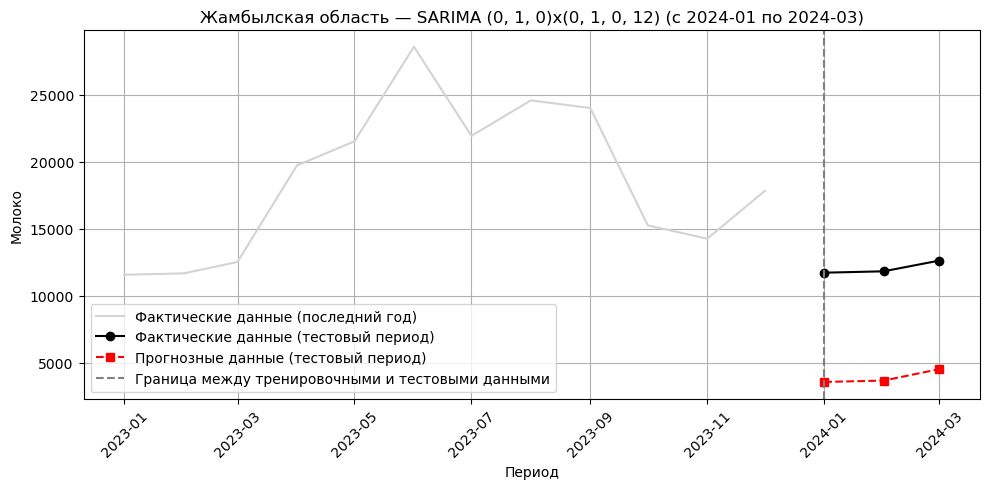

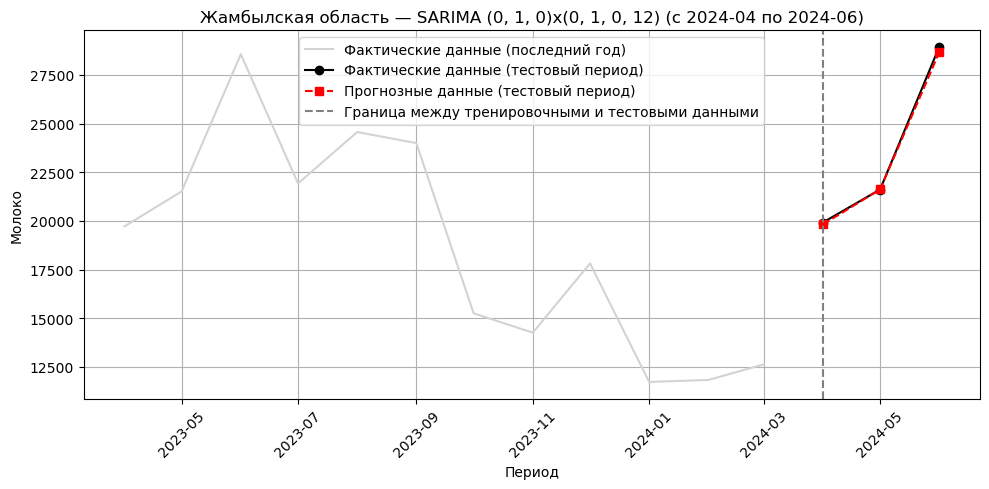

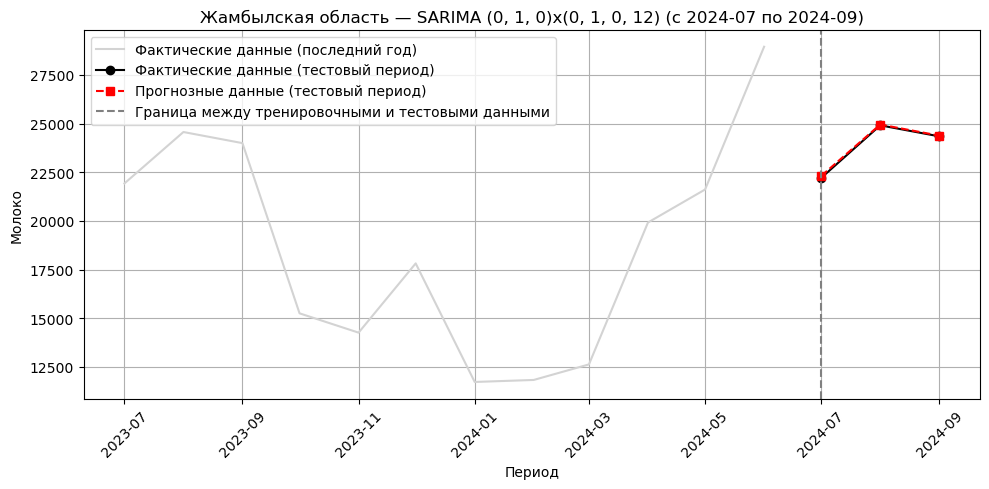

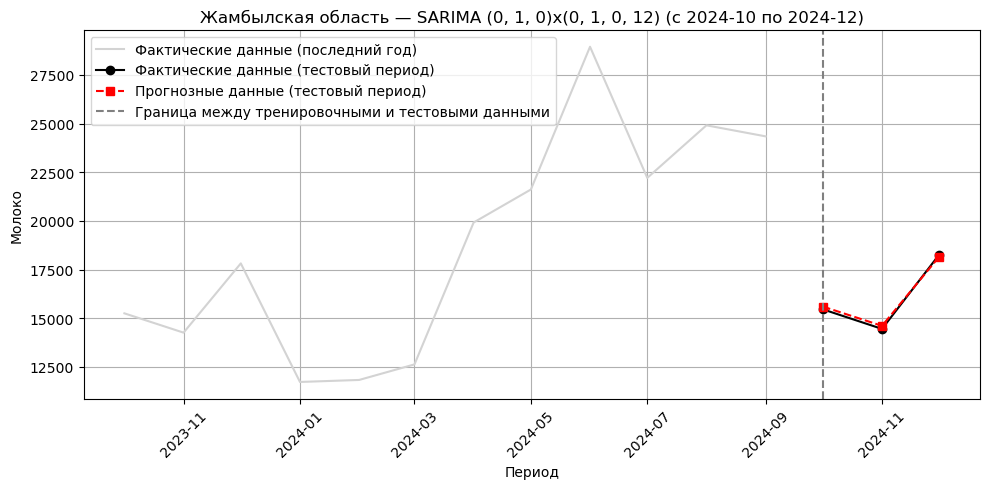

In [ ]:
# results = []

# # Определим 4 тестовых периода на 3 месяца
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Разделим данные
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=3)
#         forecast = pd.Series(forecast).reset_index(drop=True)


#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMA {model.order}x{model.seasonal_order} (с {test_start.strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()
#         # print("Zero values in y_test:", (y_test == 0).sum())


#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  8121.840337  8121.800000  67.413262    (0, 1, 0)   
1  2024-04 to 2024-06   174.059003   128.966667   0.498770    (0, 1, 0)   
2  2024-07 to 2024-09    64.820187    58.500000   0.251934    (0, 1, 0)   
3  2024-10 to 2024-12   136.086774   134.500000   0.858152    (0, 1, 0)   
4             Average  2124.201575  2110.941667  17.255529          NaN   

  Seasonal order  
0  (0, 1, 0, 12)  
1  (0, 1, 0, 12)  
2  (0, 1, 0, 12)  
3  (0, 1, 0, 12)  
4            NaN  


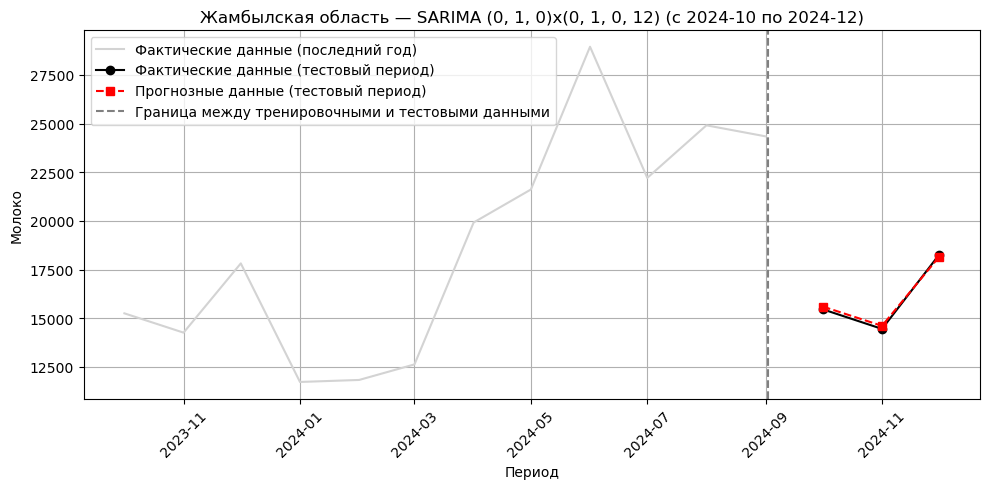

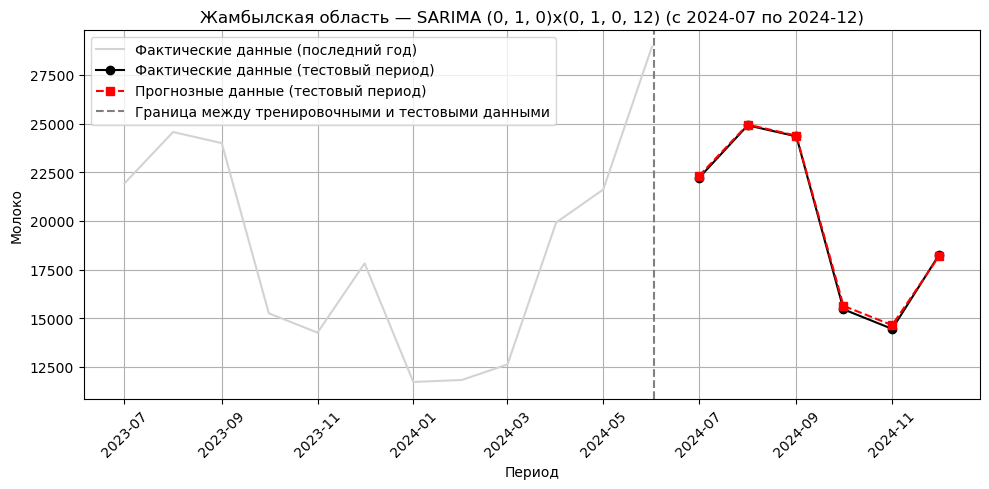

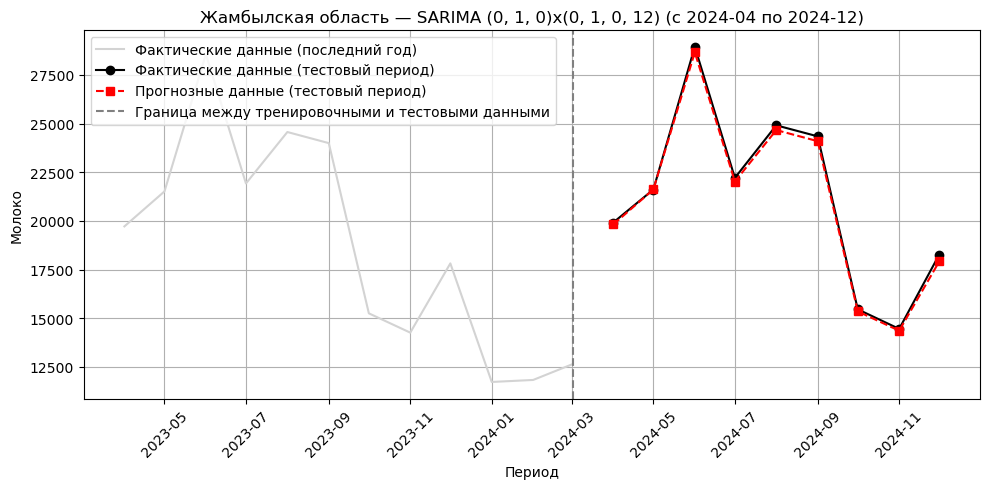

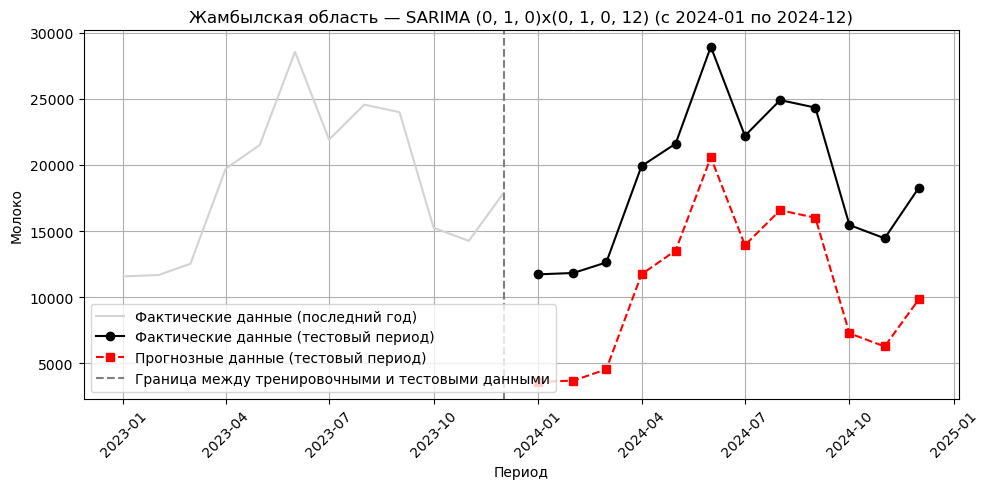

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:

#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)
    
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     try:
#         model = auto_arima(
#             y_train,
#             seasonal=True,
#             m=12,
#             stepwise=True,
#             suppress_warnings=True,
#             error_action="ignore"
#         )

#         forecast = model.predict(n_periods=horizon)
#         forecast = pd.Series(forecast).reset_index(drop=True)

#         # Оценка
#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.order,
#             "Seasonal order": model.seasonal_order
#         })

#         # График
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="red", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMA {model.order}x{model.seasonal_order} (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")

In [ ]:
# # Вывод метрик
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_row["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)


          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12   136.086774   134.500000   0.858152    (0, 1, 0)   
1  2024-07 to 2024-12   119.830686   102.600000   0.603327    (0, 1, 0)   
2  2024-04 to 2024-12   208.562160   179.677778   0.843830    (0, 1, 0)   
3  2024-01 to 2024-12  8229.754415  8228.991667  47.529906    (0, 1, 0)   
4             Average  2173.558509  2161.442361  12.458804          NaN   

  Seasonal order  
0  (0, 1, 0, 12)  
1  (0, 1, 0, 12)  
2  (0, 1, 0, 12)  
3  (0, 1, 0, 12)  
4            NaN  


#### SARIMAX

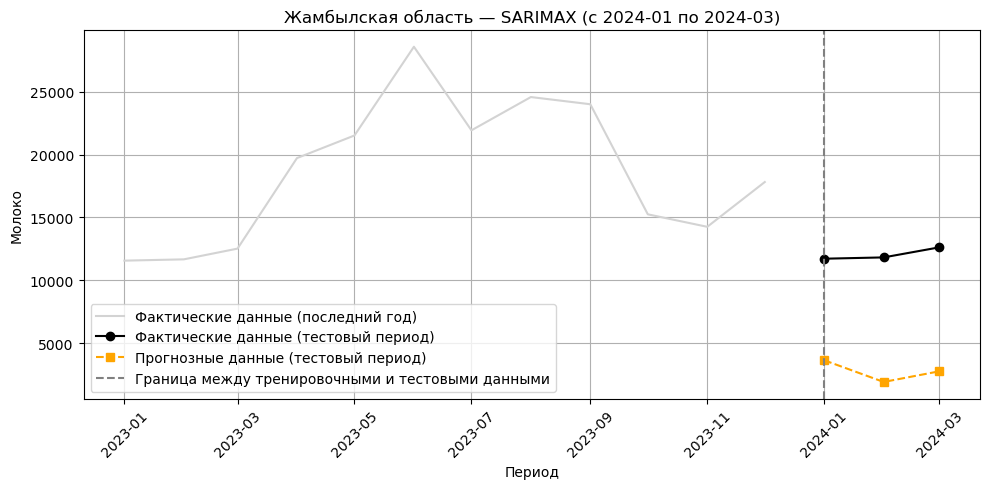

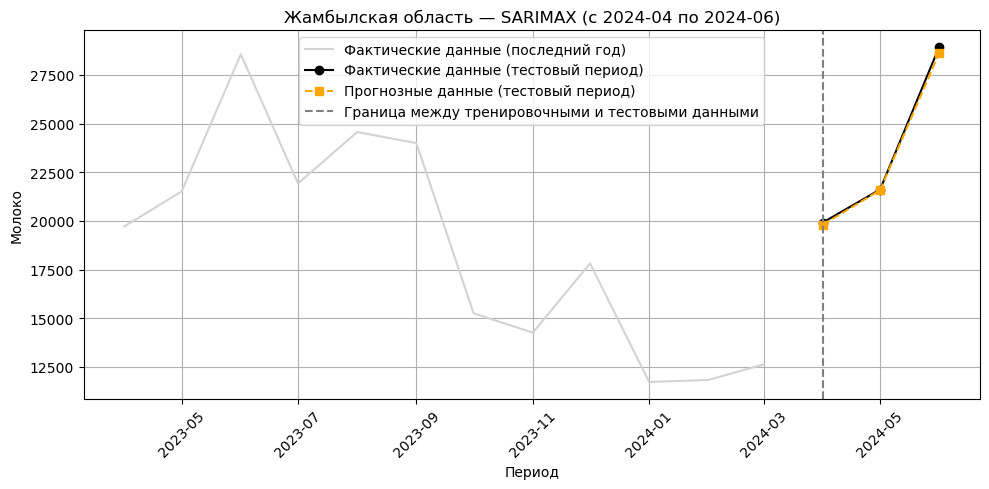

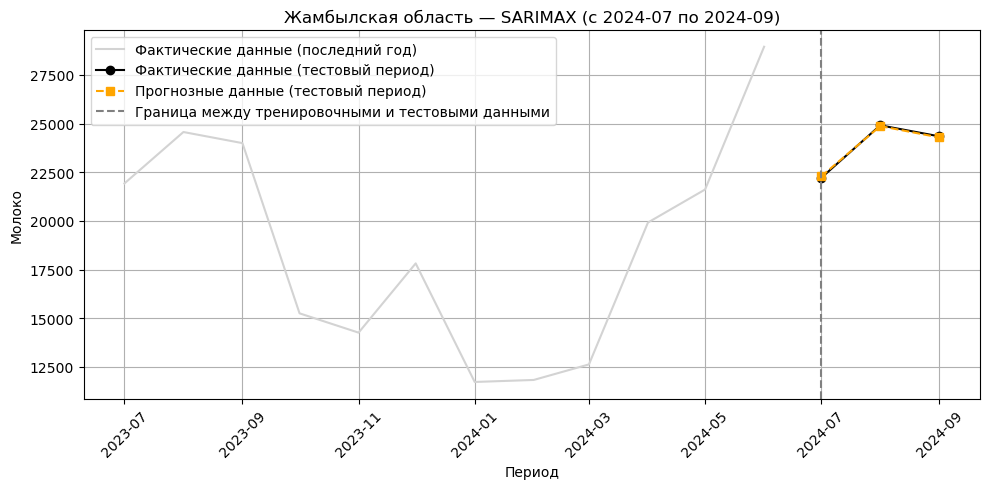

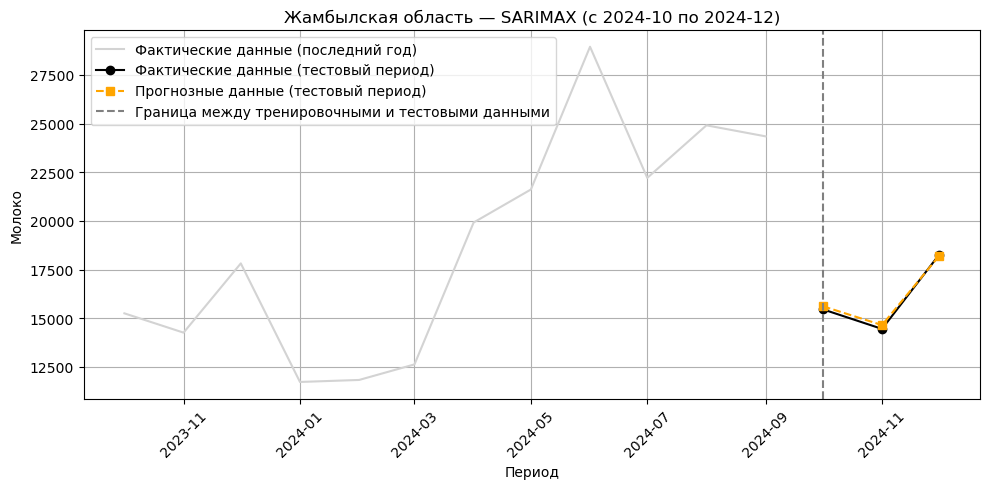

In [ ]:
# results = []

# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(0, 1, 0),
#             seasonal_order=(0, 1, 0, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=3, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMAX (с {start} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)



          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-01 to 2024-03  9305.442108  9266.569196  76.774723            0   
1  2024-04 to 2024-06   189.324732   150.509473   0.591864            0   
2  2024-07 to 2024-09    58.689250    56.804267   0.242055            0   
3  2024-10 to 2024-12   149.291987   138.081468   0.902397            0   
4             Average  2425.687019  2402.991101  19.627760                

  Seasonal order  
0              0  
1              0  
2              0  
3              0  
4                 


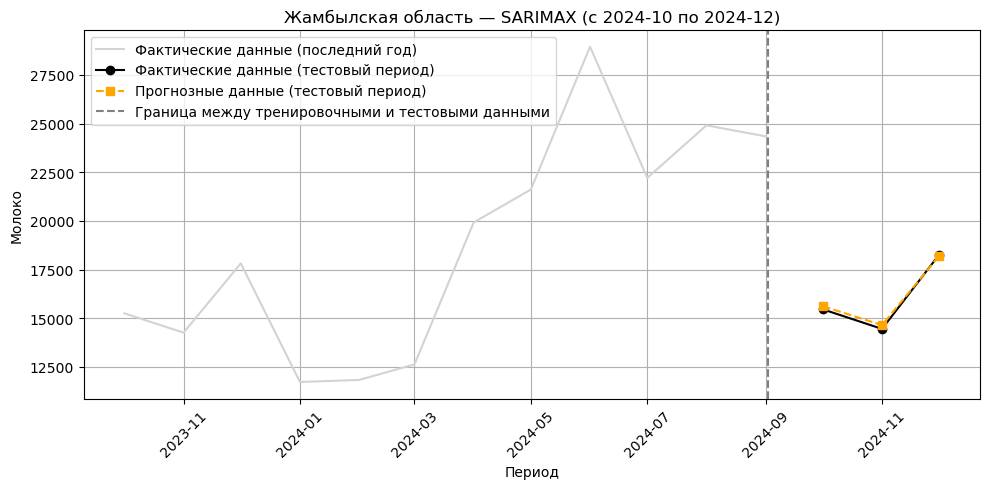

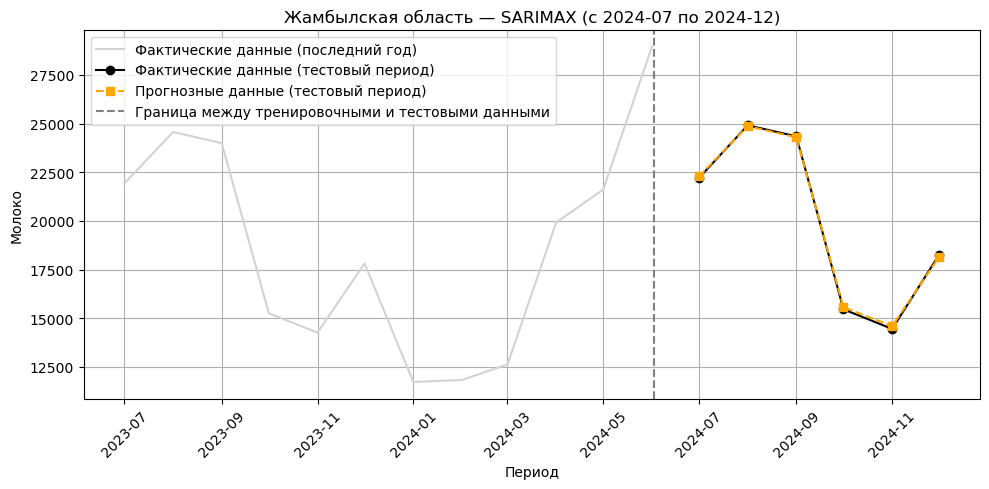

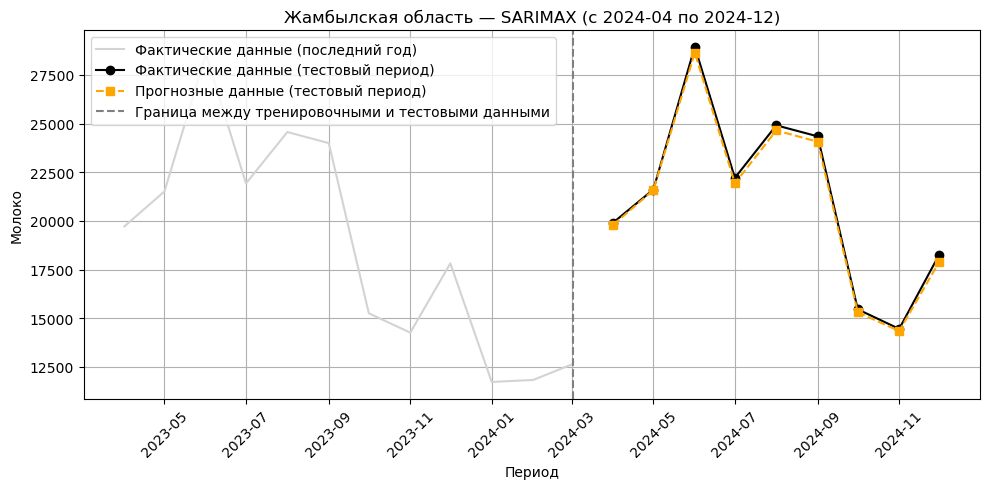

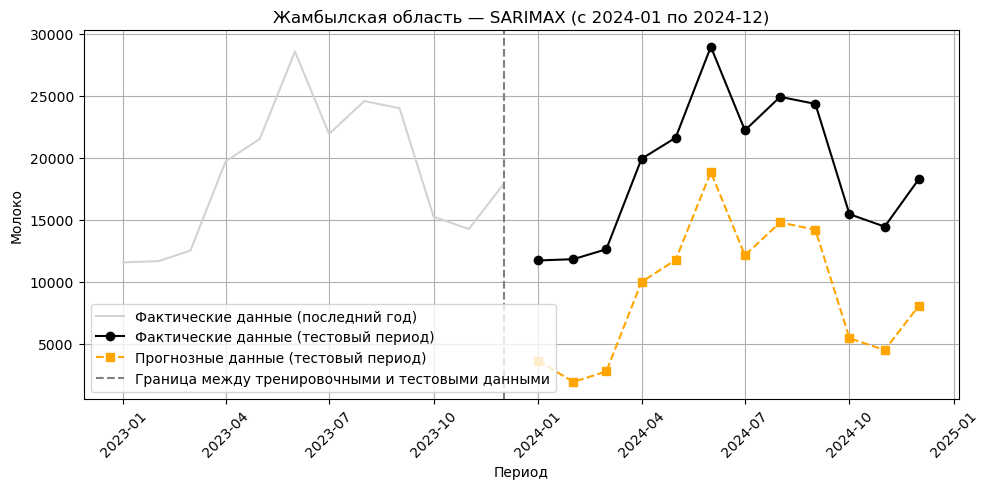

In [ ]:
# results = []

# horizons = [3, 6, 9, 12]

# for horizon in horizons:
#     # test_start = pd.to_datetime(start)
#     # test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     # Split
#     train_df = df[df["Период"] < test_start]
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)]

#     y_train = train_df[target].reset_index(drop=True)
#     y_test = test_df[target].reset_index(drop=True)

#     exog_train = train_df[features].reset_index(drop=True)
#     exog_test = test_df[features].reset_index(drop=True)

#     try:
#         model = SARIMAX(
#             endog=y_train,
#             exog=exog_train,
#             order=(0, 1, 0),
#             seasonal_order=(0, 1, 0, 12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         ).fit(disp=False)

#         forecast_res = model.get_forecast(steps=horizon, exog=exog_test)
#         forecast = forecast_res.predicted_mean.reset_index(drop=True)

#         rmse = np.sqrt(mean_squared_error(y_test, forecast))
#         mae = mean_absolute_error(y_test, forecast)
#         mape = (np.abs((y_test - forecast) / y_test).mean()) * 100

#         results.append({
#             "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#             "RMSE": rmse,
#             "MAE": mae,
#             "MAPE (%)": mape,
#             "SARIMA order": model.model_orders["ar"],
#             "Seasonal order": model.model_orders.get("seasonal_ar", None)
#         })

#         # Plot
#         plt.figure(figsize=(10, 5))
#         last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#         plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#         plt.plot(test_df["Период"], y_test, marker="o", color="black", label="Фактические данные (тестовый период)")
#         plt.plot(test_df["Период"], forecast, marker="s", linestyle="--", color="orange", label="Прогнозные данные (тестовый период)")
#         plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#         plt.title(f"Жамбылская область — SARIMAX (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#         plt.xlabel("Период")
#         plt.ylabel("Молоко")
#         plt.legend()
#         plt.grid(True)
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Ошибка в периоде {start}: {e}")


In [ ]:
# # Вывод метрик для SARIMAX
# results_df = pd.DataFrame(results)

# # Средние значения по метрикам
# avg_metrics = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg_metrics["Test period"] = "Average"
# avg_metrics["SARIMA order"] = ""
# avg_metrics["Seasonal order"] = ""

# # Добавим строку со средними значениями
# results_df = pd.concat([results_df, pd.DataFrame([avg_metrics])], ignore_index=True)

# # Вывод
# print(results_df)

          Test period         RMSE          MAE   MAPE (%) SARIMA order  \
0  2024-10 to 2024-12   149.291987   138.081468   0.902397            0   
1  2024-07 to 2024-12    95.230523    88.553090   0.502018            0   
2  2024-04 to 2024-12   236.987429   211.649533   1.000703            0   
3  2024-01 to 2024-12  9857.563331  9842.322183  56.448620            0   
4             Average  2584.768317  2570.151569  14.713434                

  Seasonal order  
0              0  
1              0  
2              0  
3              0  
4                 


#### Prophet

16:42:40 - cmdstanpy - INFO - Chain [1] start processing
16:42:40 - cmdstanpy - INFO - Chain [1] done processing


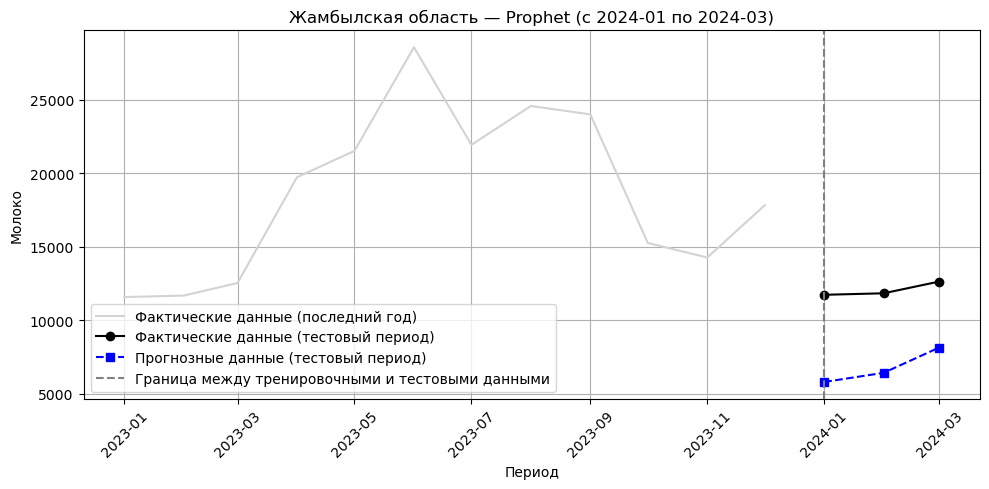

16:42:41 - cmdstanpy - INFO - Chain [1] start processing
16:42:41 - cmdstanpy - INFO - Chain [1] done processing


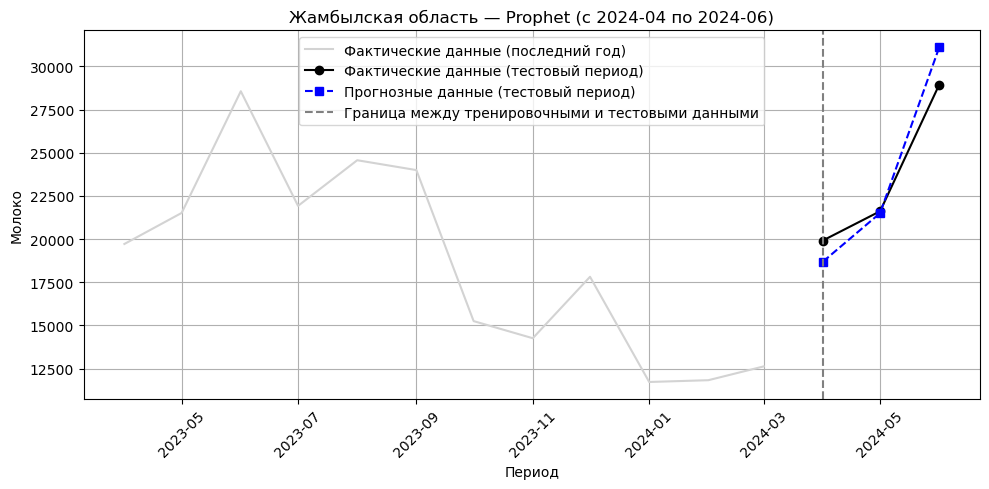

16:42:41 - cmdstanpy - INFO - Chain [1] start processing
16:42:42 - cmdstanpy - INFO - Chain [1] done processing


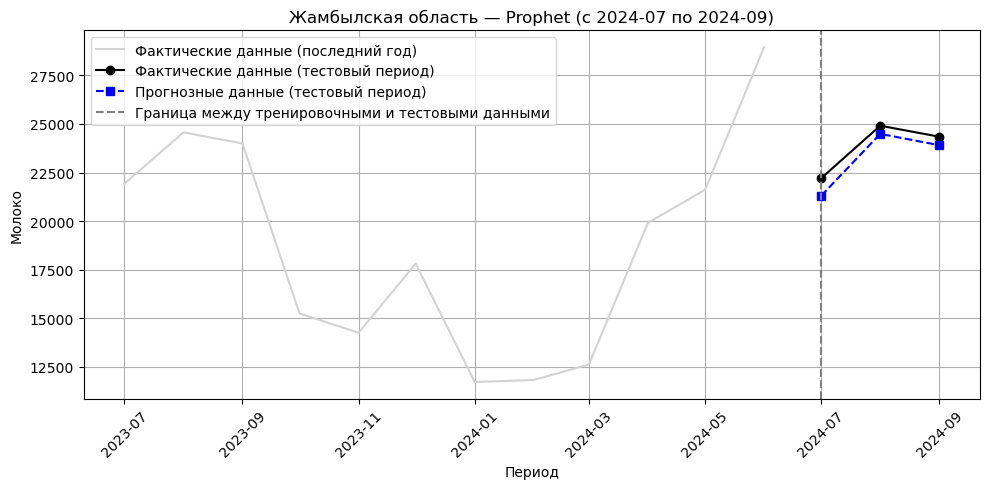

16:42:42 - cmdstanpy - INFO - Chain [1] start processing
16:42:42 - cmdstanpy - INFO - Chain [1] done processing


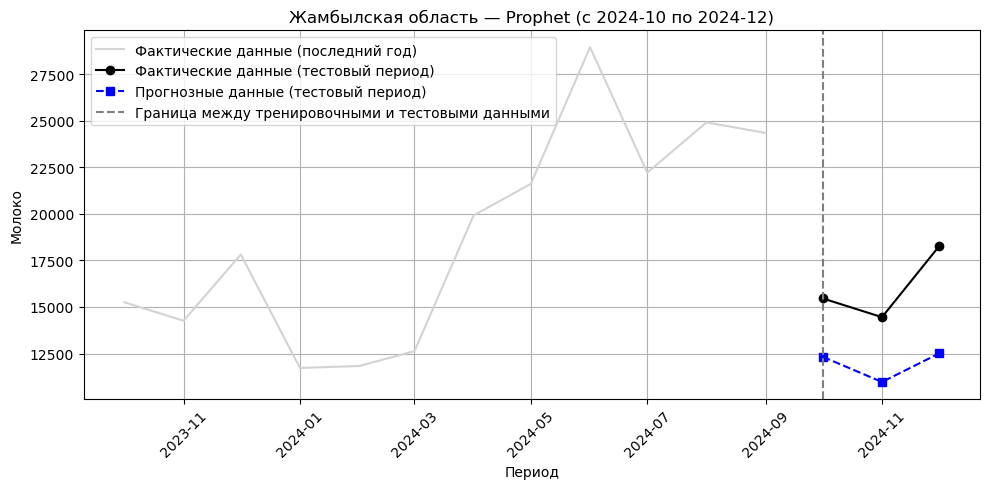

In [ ]:
# results = []

# # Define 4 test periods
# start_dates = ["2024-01", "2024-04", "2024-07", "2024-10"]

# for start in start_dates:
#     test_start = pd.to_datetime(start)
#     test_end = test_start + pd.DateOffset(months=3) - pd.DateOffset(days=1)

#     # Train/test split
#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Initialize Prophet
#     model = Prophet()

#     # Optional: add regressors
#     # model.add_regressor("Температура_t-1")
#     # prophet_train["Температура_t-1"] = train_df["Температура_t-1"].values
#     # prophet_test["Температура_t-1"] = test_df["Температура_t-1"].values

#     # Fit
#     model.fit(prophet_train)

#     # Create future dataframe
#     future = model.make_future_dataframe(periods=3, freq="M")
#     forecast = model.predict(future)
# # forecast
# # prophet_test

#     # Extract forecast for test period only
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluate
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{start} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Жамбылская область — Prophet (с {start} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Молоко")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()



In [ ]:
# results_df = pd.DataFrame(results)
# avg = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# avg["Test period"] = "Average"
# results_df = pd.concat([results_df, pd.DataFrame([avg])], ignore_index=True)
# print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-01 to 2024-03  5306.623545  5272.994012  43.919504
1  2024-04 to 2024-06  1437.204494  1166.462360   4.713935
2  2024-07 to 2024-09   628.728219   587.216929   2.518354
3  2024-10 to 2024-12  4287.004688  4125.464442  25.297553
4             Average  2914.890237  2788.034436  19.112336


16:42:43 - cmdstanpy - INFO - Chain [1] start processing
16:42:43 - cmdstanpy - INFO - Chain [1] done processing


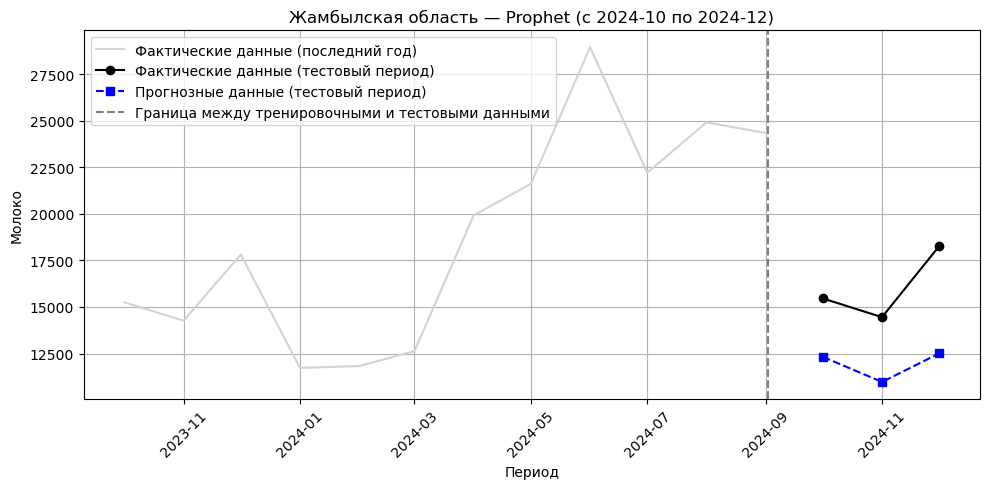

16:42:44 - cmdstanpy - INFO - Chain [1] start processing
16:42:44 - cmdstanpy - INFO - Chain [1] done processing


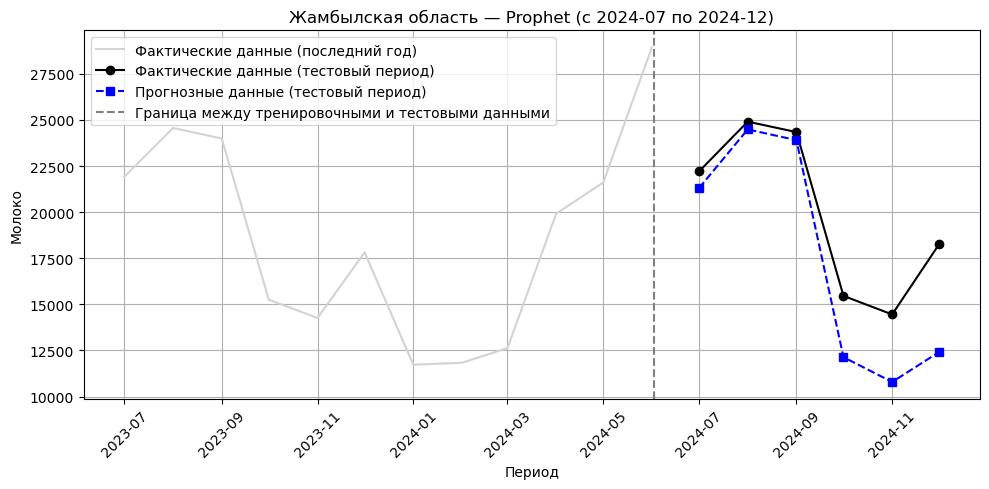

16:42:45 - cmdstanpy - INFO - Chain [1] start processing
16:42:45 - cmdstanpy - INFO - Chain [1] done processing


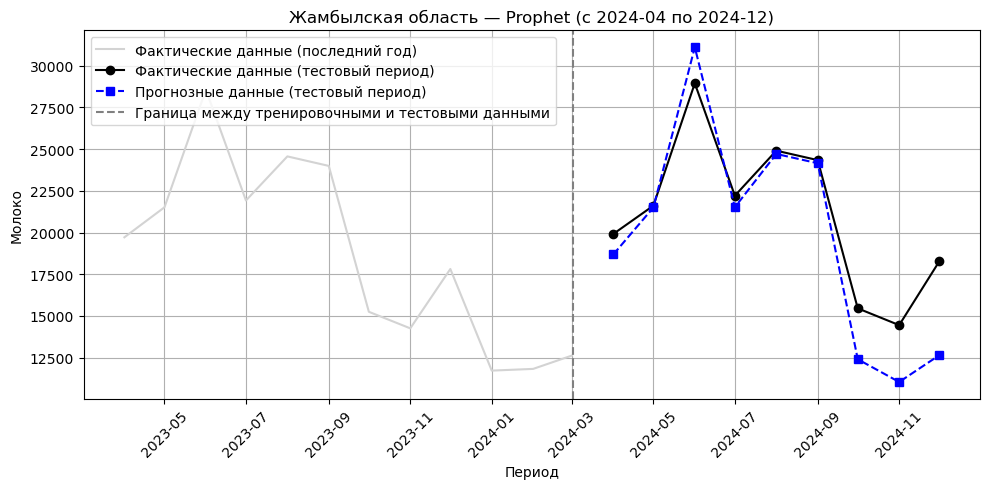

16:42:45 - cmdstanpy - INFO - Chain [1] start processing
16:42:46 - cmdstanpy - INFO - Chain [1] done processing


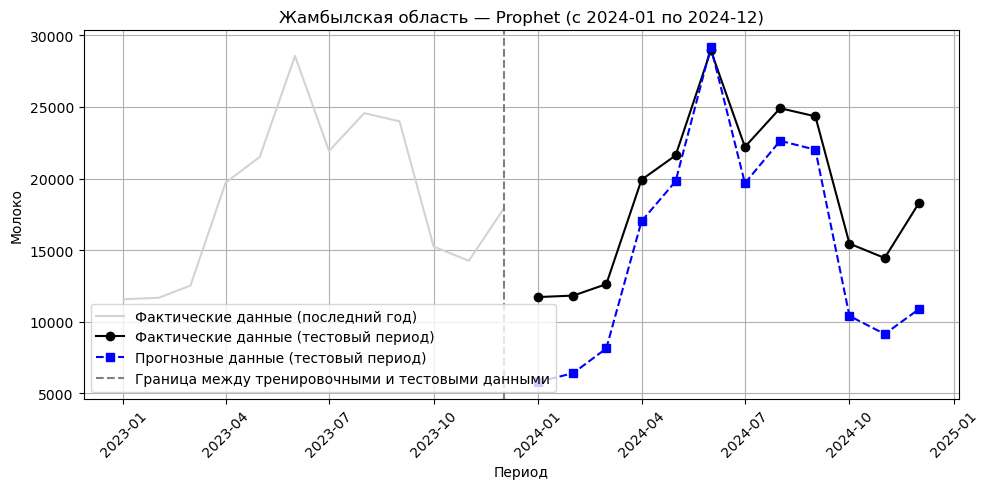

In [ ]:
# horizons = [3, 6, 9, 12]
# results = []

# for horizon in horizons:

#     # Define train/test split
#     test_end = pd.to_datetime("2024-12")
#     test_start = test_end - pd.DateOffset(months=horizon) + pd.DateOffset(days=1)

#     train_df = df[df["Период"] < test_start].copy()
#     test_df = df[(df["Период"] >= test_start) & (df["Период"] <= test_end)].copy()

#     # Prophet format
#     prophet_train = train_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})
#     prophet_test = test_df[["Период", target]].rename(columns={"Период": "ds", target: "y"})

#     # Fit Prophet
#     model = Prophet()
#     model.fit(prophet_train)

#     # Forecast
#     future = model.make_future_dataframe(periods=horizon, freq="M")
#     forecast = model.predict(future)

#     # Extract matching forecasted months
#     forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"] - pd.DateOffset(days=1))].copy()
#     y_pred = forecast_test["yhat"].values
#     y_true = prophet_test["y"].values

#     # Evaluation
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = (np.abs((y_true - y_pred) / y_true).mean()) * 100

#     results.append({
#         "Test period": f"{(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} to {test_end.strftime('%Y-%m')}",
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE (%)": mape
#     })

#     # Plot
#     plt.figure(figsize=(10, 5))
#     last_train = train_df[train_df["Период"] >= (test_start - pd.DateOffset(months=12))]
#     plt.plot(last_train["Период"], last_train[target], color="lightgray", label="Фактические данные (последний год)")
#     plt.plot(test_df["Период"], test_df[target], marker="o", color="black", label="Фактические данные (тестовый период)")
#     plt.plot(test_df["Период"], y_pred, marker="s", linestyle="--", color="blue", label="Прогнозные данные (тестовый период)")
#     plt.axvline(test_start, color="gray", linestyle="--", label="Граница между тренировочными и тестовыми данными")
#     plt.title(f"Жамбылская область — Prophet (с {(test_start + pd.DateOffset(months=1)).strftime('%Y-%m')} по {test_end.strftime('%Y-%m')})")
#     plt.xlabel("Период")
#     plt.ylabel("Молоко")
#     plt.legend()
#     plt.grid(True)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()




In [ ]:
# # Summary table
# results_df = pd.DataFrame(results)
# avg_row = results_df[["RMSE", "MAE", "MAPE (%)"]].mean().to_dict()
# results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)

# print(results_df)

          Test period         RMSE          MAE   MAPE (%)
0  2024-10 to 2024-12  4287.004688  4125.464442  25.297553
1  2024-07 to 2024-12  3158.965503  2433.061767  14.403451
2  2024-04 to 2024-12  2565.976956  1850.133176  10.319860
3  2024-01 to 2024-12  4296.947339  3802.502283  24.615514
4                 NaN  3577.223622  3052.790417  18.659095


strength of correlation:
https://link.springer.com/article/10.1057/jt.2009.5#
https://resources.nu.edu/statsresources/correlation